In [287]:
import pandas as pd
import numpy as np
from datetime import datetime
import re
import sys
import matplotlib.pyplot as plt
from functools import reduce

In [ ]:
ticket = "VESTA"
ruta = "Mexico/"
archivo = f'{ticket}.xlsx'
ruta_archivo = ruta + archivo
archivo_stock = f"Mexico/DatosHistoricos/Datos históricos {ticket}.MX"
archivo_market = "Datos históricos S&P_BMV IRT"
archivo_market_cetes = "cetes_historicos"
archivo_inflacion_mexico = "INFLACION_mexico"
market_risk_premium = 0.07


In [289]:
df_err = pd.read_excel(ruta_archivo, header=19)
# Filas a eliminar (ajustar índices para que sean 0-based)
filas_a_eliminar = [1, 17, 55, 88, 153, 194, 218,256]
# Eliminar las filas
df_err = df_err.drop(filas_a_eliminar)
df_err.columns = df_err.iloc[0]
if '\t' in df_err.columns:
    df = df_err.drop(columns=['\t'])
df_err = df_err[1:].reset_index(drop=True)

In [290]:
cols = df_err.columns.tolist()
ttm_idx = cols.index("TTM/current")
df_hist = df_err.iloc[:, :ttm_idx].copy() 

valid_headers = []

row = df_hist.loc[df_hist["Fiscal Period"].eq("Revenue per Share")].iloc[0]

valid_headers = [
    col for col in df_hist.columns
    if col != "Fiscal Period"
    and not pd.isna(row[col])
    and not (isinstance(row[col], str) and row[col].strip() == "-")
]

valid_years = [int(h[-4:]) for h in valid_headers]

last_20_years = valid_years[-20:]

last_20_years

[2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024]

In [ ]:
def calcular_crecimiento_ipc(archivo_csv, anio_cierre, periodo_anos=5):
    df = pd.read_csv(f"{archivo_csv}.csv")
    df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d.%m.%Y')
    df['Cierre'] = df['Cierre'].str.replace(',', '').astype(float)
    df = df.sort_values('Fecha')
    
    # Filtrar datos del año de cierre
    df_ano = df[df['Fecha'].dt.year == anio_cierre]
    if df_ano.empty:
        raise ValueError(f"No hay datos para el año {anio_cierre}")
    fecha_final = df_ano['Fecha'].max()
    fecha_inicio = fecha_final - pd.DateOffset(years=periodo_anos)
    
    df_filtrado = df[(df['Fecha'] >= fecha_inicio) & (df['Fecha'] <= fecha_final)]
    if df_filtrado.shape[0] < 2:
        raise ValueError("Datos insuficientes para el período solicitado")
    
    precio_inicial = df_filtrado.iloc[0]['Cierre']
    precio_final = df_filtrado.iloc[-1]['Cierre']
    
    tasa = ((precio_final / precio_inicial) ** (1 / periodo_anos)) - 1
    return fecha_inicio.date(), fecha_final.date(), tasa 


crecimiento_ipc_porcentaje_años = []

for año in last_20_years:
    fi, ff, tasa = calcular_crecimiento_ipc(archivo_market, año)
    crecimiento_ipc_porcentaje_años.append({
        "año_cierre": año,
        "fecha_inicio": fi,
        "fecha_final": ff,
        "CAGR_%": round(tasa, 4)
    })



In [ ]:

data_cetes = pd.read_excel(archivo_market_cetes + '.xlsx' , header=17)

data_cetes['Fecha'] = pd.to_datetime(data_cetes['Fecha'], format='%d/%m/%Y')
data_cetes = data_cetes.rename(columns={data_cetes.columns[1]: 'Rendimiento'})

data_cetes = data_cetes[data_cetes['Fecha'].dt.year.isin(last_20_years)]

promedio_cetes = (
    data_cetes
    .groupby(data_cetes['Fecha'].dt.year)['Rendimiento']
    .mean()
    .reset_index()
    .rename(columns={'Fecha': 'Año', 'Rendimiento': 'Promedio_Anual'})
)
promedio_cetes['Promedio_Anual'] = promedio_cetes['Promedio_Anual'].round(4)
print(promedio_cetes)

     Año  Promedio_Anual
0   2010          4.8125
1   2011          4.6245
2   2012          4.5804
3   2013          3.9327
4   2014          3.2781
5   2015          3.4980
6   2016          4.6900
7   2017          7.0847
8   2018          8.0373
9   2019          7.8175
10  2020          5.2056
11  2021          5.2381
12  2022          9.2586
13  2023         11.4710
14  2024         10.8755


c:\Users\mar_c\OneDrive\Documentos\GuruFocus\guru_focus\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [ ]:

data_inflacion_mexico = pd.read_excel(archivo_inflacion_mexico + '.xlsx')

# Filtrado y extracción
resultados_inf_mexico = []
for año in last_20_years:
    fila = data_inflacion_mexico[data_inflacion_mexico['Año'] == año]
    if not fila.empty:
        tasa = fila.iloc[0]['Tasa de Inflación']/100
        resultados_inf_mexico.append({"Año": año, "Tasa de Inflación": round(tasa, 4)})
    else:
        resultados_inf_mexico.append({"Año": año, "Tasa de Inflación": None})

# Convertir en DataFrame (o lo que prefieras)
df_resultados_inf_mexico = pd.DataFrame(resultados_inf_mexico)
print(df_resultados_inf_mexico)


     Año  Tasa de Inflación
0   2010             0.0440
1   2011             0.0382
2   2012             0.0357
3   2013             0.0397
4   2014             0.0408
5   2015             0.0213
6   2016             0.0336
7   2017             0.0677
8   2018             0.0483
9   2019             0.0283
10  2020             0.0315
11  2021             0.0736
12  2022             0.0782
13  2023             0.0466
14  2024             0.0421


In [295]:
promedio_cetes['Promedio_Anual'] = promedio_cetes['Promedio_Anual'] / 100

In [296]:

df_stock  = pd.read_csv(f"{archivo_stock}.csv")
df_market = pd.read_csv(f"{archivo_market}.csv")


df_stock['Fecha'] = pd.to_datetime(df_stock['Fecha'], format='%Y-%m-%d', errors='coerce')
df_stock = df_stock.dropna(subset=['Fecha']).sort_values('Fecha').copy()

df_stock['Cierre'] = (
    df_stock['Cierre']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df_stock['Cierre'] = pd.to_numeric(df_stock['Cierre'], errors='coerce')
df_stock = df_stock.dropna(subset=['Cierre']).copy()

df_stock['Rend_Stock'] = df_stock['Cierre'].pct_change()
df_stock = df_stock.dropna(subset=['Rend_Stock']).copy()


df_market['Fecha'] = pd.to_datetime(df_market['Fecha'], format='%d.%m.%Y', errors='coerce')
df_market = df_market.dropna(subset=['Fecha']).sort_values('Fecha').copy()

df_market['Cierre'] = (
    df_market['Cierre']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df_market['Cierre'] = pd.to_numeric(df_market['Cierre'], errors='coerce')
df_market = df_market.dropna(subset=['Cierre']).copy()

df_market['Rend_Market'] = df_market['Cierre'].pct_change()
df_market = df_market.dropna(subset=['Rend_Market']).copy()


In [297]:
# Asegurar datetime
df_stock['Fecha'] = pd.to_datetime(df_stock['Fecha'])
df_market['Fecha'] = pd.to_datetime(df_market['Fecha'])

# Nos quedamos solo con lo que necesitamos
df_stock_beta = df_stock[['Fecha', 'Rend_Stock']].copy()
df_market_beta = df_market[['Fecha', 'Rend_Market']].copy()

df_beta = pd.merge_asof(
    df_stock_beta.sort_values('Fecha'),
    df_market_beta.sort_values('Fecha'),
    on='Fecha',
    direction='nearest'
)


df_beta['Año'] = df_beta['Fecha'].dt.year

def beta_anual(grupo):
    if len(grupo) < 10:   # protección: muy pocos datos
        return np.nan
    cov = grupo['Rend_Stock'].cov(grupo['Rend_Market'])
    var_m = grupo['Rend_Market'].var()
    return cov / var_m if var_m != 0 else np.nan

df_beta_resultado = (
    df_beta 
    .groupby('Año')
    .apply(beta_anual)
    .reset_index(name='Beta')
)

df_beta_resultado = df_beta_resultado.dropna(subset=['Beta'])

C:\Users\mar_c\AppData\Local\Temp\ipykernel_21420\2539571452.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(beta_anual)


In [298]:
df_beta_20y = df_beta_resultado[df_beta_resultado['Año'].isin(last_20_years)].copy()
df_beta_20y

,Año,Beta
0,2012,-0.097452
1,2013,0.568301
2,2014,0.750720
3,2015,0.198864
4,2016,0.569156
5,2017,0.612834
6,2018,0.988748
7,2019,0.351481
8,2020,0.650935
9,2021,0.614292


In [ ]:
# Obtengo los DF para datos anulaes y trimestrales
indice_ttm = df_err.columns.get_loc('TTM/current')
df_anual = df_err.iloc[:, :indice_ttm + 1]
df_trimestral = df_err.iloc[:, indice_ttm + 1:]
df_trimestral.insert(0, 'Fiscal Period', df_err['Fiscal Period'])


In [ ]:
columna_anterior = df_anual.columns[indice_ttm - 1]
anio_anterior = int(columna_anterior[-4:])
# Identificar las columnas que contienen un año en su nombre
pattern = re.compile(r'\d{4}')
columnas_con_anio = [col for col in df_anual.columns if pattern.search(col)]

anio_limite = min(last_20_years)

columnas_filtradas = [col for col in columnas_con_anio if int(
    pattern.search(col).group()) >= anio_limite]

# Asegurarse de incluir 'Fiscal Period' y 'TTM/current' si están presentes
columnas_especiales = ['Fiscal Period', 'TTM/current']
columnas_filtradas = [
    col for col in df_anual.columns if col in columnas_especiales] + columnas_filtradas

df_anual_filtrado = df_anual[columnas_filtradas]

# Mover la columna 'TTM/current' al final
if 'TTM/current' in df_anual_filtrado.columns:
    columnas_ordenadas = [
        col for col in df_anual_filtrado.columns if col != 'TTM/current'] + ['TTM/current']
    df_anual_filtrado = df_anual_filtrado[columnas_ordenadas]

df_anual_filtrado = df_anual_filtrado.fillna(0)


In [301]:
df_anual_filtrado

,Fiscal Period,Dec2010,Dec2011,Dec2012,Dec2013,Dec2014,Dec2015,Dec2016,Dec2017,Dec2018,Dec2019,Dec2020,Dec2021,Dec2022,Dec2023,Dec2024,TTM/current
0,Revenue per Share,1.676,2.629,2.252,1.683,1.984,2.155,2.944,3.441,4.445,4.696,5.215,4.856,5.03,4.796,5.788,6.114
1,EBITDA per Share,0.246,3.031,3.201,4.354,2.1,1.58,3.912,5.584,5.487,7.347,5.847,9.298,9.554,9.56,10.77,5.893
2,EBIT per Share,0.244,3.028,3.199,4.352,2.098,1.575,3.901,5.573,5.468,7.299,5.796,9.25,9.513,9.525,10.738,5.854
3,Earnings per Share (Diluted),-0.352,0.696,1.801,2.602,0.726,-0.102,1.476,3.97,3.115,4.374,2.329,5.516,6.883,7.08,5.124,1.261
4,EPS without NRI,0.587,0.055,0.739,0.69,0.515,0.174,0.515,1.782,1.841,1.854,1.228,1.872,2.317,2.359,0.907,0.536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,Profitability Rank,0,0,0,0,0,4,5,5,6,7,7,7,7,6,6,6
253,GF Value Rank,0,0,0,0,0,10,4,2,4,9,9,1,1,1,10,10
254,Growth Rank,0,0,0,0,0,0,4,4,7,4,5,5,6,9,8,6
255,Momentum Rank,0,0,0,0,0,5,8,4,10,10,8,4,9,10,5,7


In [ ]:
pattern = re.compile(r"\d{4}")

columnas_con_anio_trimestral = [
    col for col in df_trimestral.columns
    if col != "Fiscal Period" and pattern.search(str(col))
]

anio_min = min(last_20_years)
anio_max = max(last_20_years)

columnas_filtradas_trimestral = [
    col for col in columnas_con_anio_trimestral
    if anio_min <= int(pattern.search(str(col)).group()) <= anio_max
]

columnas_filtradas_trimestral.sort(key=lambda c: int(pattern.search(str(c)).group()))

columnas_especiales_trimestral = ["Fiscal Period"]

df_trimestral_filtrado = df_trimestral[columnas_especiales_trimestral + columnas_filtradas_trimestral].copy()
df_trimestral_filtrado = df_trimestral_filtrado.fillna(0)

In [303]:
df_anual_filtrado = df_anual_filtrado.drop(columns=["TTM/current"])

In [304]:
def limpiar_df_financiero(df):
    df = df.copy()

    # Reemplazar '-' por NaN en todo el DF
    df.replace('-', np.nan, inplace=True)

    # Todas las columnas excepto 'Fiscal Period' a numéricas
    cols_datos = df.columns.drop('Fiscal Period')

    df[cols_datos] = df[cols_datos].apply(
        pd.to_numeric, errors='coerce'
    )

    return df

df_anual_filtrado = limpiar_df_financiero(df_anual_filtrado)
df_trimestral_filtrado = limpiar_df_financiero(df_trimestral_filtrado)

C:\Users\mar_c\AppData\Local\Temp\ipykernel_21420\1578466456.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('-', np.nan, inplace=True)


In [305]:
df_anual_filtrado = df_anual_filtrado.dropna(axis=1, how='all')
df_trimestral_filtrado = df_trimestral_filtrado.dropna(axis=1, how='all')

In [306]:
# Crear DataFrame vacío con las columnas anuales
razones_financieras = pd.DataFrame(
    columns=df_anual_filtrado.columns.difference(['Fiscal Period']))


def agregar_razon_financiera(df_anual_filtrado, fila_numerador, nombre_nueva_fila, *filas_denominadoras, como_porcentaje=True):

    global razones_financieras

    # Obtener la fila numerador
    fila_num = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila_numerador].iloc[0, 1:]

    # Obtener y sumar las filas denominadoras
    fila_den = sum(df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila].iloc[0, 1:].values for fila in filas_denominadoras)

    # Calcular la razón financiera, manejando la división por cero
    razon_financiera = []
    for num, den in zip(fila_num.values, fila_den):
        if den != 0:
            razon = num / den
            if como_porcentaje:
                razon *= 100
            razon_financiera.append(f"{razon:.2f}")
        else:
            razon_financiera.append("no deuda")

    # Agregar el resultado al DataFrame
    razones_financieras.loc[nombre_nueva_fila] = razon_financiera

def agregar_razon_financiera_numerador(df_anual_filtrado, nombre_nueva_fila, fila_denominador, fila_numerador_1, fila_numerador_2, como_porcentaje=True):

    global razones_financieras

    # Obtener las filas numeradoras
    fila_num_1 = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila_numerador_1].iloc[0, 1:]
    fila_num_2 = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila_numerador_2].iloc[0, 1:]

    # Obtener la fila denominador
    fila_den = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila_denominador].iloc[0, 1:]

    # Restar las filas numeradoras
    resta_numeradores = fila_num_1.values - fila_num_2.values

    # Calcular la razón financiera, manejando la división por cero
    razon_financiera = []
    for num, den in zip(resta_numeradores, fila_den.values):
        if den != 0:
            razon = num / den
            if como_porcentaje:
                razon *= 100
            razon_financiera.append(f"{razon:.2f}")
        else:
            razon_financiera.append("no deuda")

    # Agregar el resultado al DataFrame razones_financieras
    razones_financieras.loc[nombre_nueva_fila] = razon_financiera

def agregar_fila(df_anual_filtrado, fila_nombre, nombre_nueva_fila):

    global razones_financieras

    # Obtener la fila relevante
    fila = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == fila_nombre].iloc[0, 1:]

    # Agregar el resultado al DataFrame
    razones_financieras.loc[nombre_nueva_fila] = fila.values

def agregar_crecimiento_anual(fila_nombre, nombre_nueva_fila):

    global razones_financieras

    # Obtener la fila relevante
    fila = razones_financieras.loc[fila_nombre].astype(float)

    # Calcular el crecimiento año a año (YoY)
    crecimiento_anual = fila.pct_change() * 100

    # Reemplazar NaN por 0
    crecimiento_anual = crecimiento_anual.fillna(0)

    # Formatear el resultado a dos decimales
    crecimiento_anual_formateado = [f"{x:.2f}" for x in crecimiento_anual]

    # Agregar el resultado al DataFrame
    razones_financieras.loc[nombre_nueva_fila] = crecimiento_anual_formateado

def dividir_filas_razones_financieras(fila_numerador, fila_denominador, nombre_nueva_fila, como_porcentaje=True):
    global razones_financieras

    # Obtener las filas relevantes para el cálculo
    fila_num = razones_financieras.loc[fila_numerador].astype(float)
    fila_den = razones_financieras.loc[fila_denominador].astype(float)

    # Calcular la razón financiera
    razon_financiera = fila_num.values / fila_den.values

    # Convertir a porcentaje si es necesario
    if como_porcentaje:
        razon_financiera *= 100

    # Reemplazar NaN por 0
    razon_financiera = pd.Series(razon_financiera).fillna(0).values

    # Formatear el resultado a dos decimales
    razon_financiera_formateada = [f"{x:.2f}" for x in razon_financiera]

    # Agregar el resultado al DataFrame
    razones_financieras.loc[nombre_nueva_fila] = razon_financiera_formateada



In [307]:
# Llamadas a la función con el nuevo orden de parámetros
agregar_razon_financiera(df_anual_filtrado, 'Depreciation, Depletion and Amortization', 'Amortizacion(%)', 'Gross Profit', como_porcentaje=True)
agregar_razon_financiera(df_anual_filtrado, 'Net Income', 'Beneficio Neto(%)', 'Revenue', como_porcentaje=True)
agregar_fila(df_anual_filtrado, 'Net Income', 'Beneficio Neto')
agregar_razon_financiera(df_anual_filtrado, 'Gross Profit', 'Margen Bruto(%)', 'Revenue', como_porcentaje=True)
agregar_razon_financiera(df_anual_filtrado, 'Operating Income', 'Margen Operativo(%)', 'Revenue', como_porcentaje=True)
agregar_razon_financiera(df_anual_filtrado, 'Net Income', 'EPS', 'Shares Outstanding (Diluted Average)', como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado, 'Revenue', 'Revenue Per Share', 'Shares Outstanding (Diluted Average)', como_porcentaje=False)
agregar_fila(df_anual_filtrado, 'Shares Outstanding (Diluted Average)', '# de Acciones')
agregar_fila(df_anual_filtrado, 'Revenue', 'Ventas')
agregar_crecimiento_anual('Beneficio Neto', 'Crecimiento Beneficio Neto')
agregar_crecimiento_anual('Ventas', 'Crecimiento Ventas')
agregar_fila(df_anual_filtrado, 'Cost of Goods Sold', 'Costo de Ventas')
agregar_crecimiento_anual('Costo de Ventas', 'Crecimiento Costo de Ventas')
agregar_fila(df_anual_filtrado, 'Total Inventories', 'Inventarios')
agregar_crecimiento_anual('Inventarios', 'Crecimiento Inventarios')
agregar_razon_financiera(df_anual_filtrado, '  Accounts Receivable', 'Cuentas por cobrar/ventas', 'Revenue', como_porcentaje=True)
agregar_fila(df_anual_filtrado, 'Dividends per Share', 'Dividendos por Accion')
agregar_fila(df_anual_filtrado, 'Free Cash Flow', 'Flujo de Caja Libre')
dividir_filas_razones_financieras('Flujo de Caja Libre', 'Ventas', 'FCF/ventas',True)
dividir_filas_razones_financieras('Flujo de Caja Libre','# de Acciones','Free cash flow per share',True)
agregar_razon_financiera(df_anual_filtrado,'Free Cash Flow','FCF/DEBT','Short-Term Debt & Capital Lease Obligation','Long-Term Debt & Capital Lease Obligation',como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado,'Free Cash Flow','FCF/DEBT corto plazo','Short-Term Debt & Capital Lease Obligation',como_porcentaje=False)
dividir_filas_razones_financieras('Dividendos por Accion',"EPS",'Dividend Payout Ratio',True)
agregar_razon_financiera(df_anual_filtrado,'Net Income','Net Income vs Deuda Largo Plazo','Long-Term Debt & Capital Lease Obligation',como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado,'Total Liabilities','Pasivo/Fondos Propios','Total Equity',como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado,'Total Current Assets','Ratio de Solvencia','Total Current Liabilities',como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado,'Long-Term Debt & Capital Lease Obligation','Deuda/Capital','Total Equity',como_porcentaje=False)
agregar_razon_financiera(df_anual_filtrado,'  Interest Expense','Gasto financiero','Operating Income',como_porcentaje=True) ##Interes Expense viene negativo, tenerlo en cuenta ya que si queda positivo seria malo ya que el operating income es tambien negativo
agregar_razon_financiera(df_anual_filtrado,'Total Inventories','Inventory to current Assetis','Total Current Assets',como_porcentaje=True)
agregar_fila(df_anual_filtrado,'Cash Conversion Cycle','Net Trading Cycle')
agregar_fila(df_anual_filtrado,'PEG Ratio','PEGY Ratio')
agregar_fila(df_anual_filtrado,'PE Ratio','PER')
agregar_fila(df_anual_filtrado,'PS Ratio','P/S Ratio')
agregar_razon_financiera(df_anual_filtrado,'  Accounts Receivable','Receivable to Current Assets','Total Current Assets',como_porcentaje=True)
agregar_fila(df_anual_filtrado,'ROA %','ROA%')
agregar_fila(df_anual_filtrado,'ROE %','ROE%')
agregar_razon_financiera(df_anual_filtrado,'Total Assets','ROB','Total Equity',como_porcentaje=False)
agregar_fila(df_anual_filtrado,'ROIC %','ROIC %')
agregar_fila(df_anual_filtrado,'WACC %','WACC %')
agregar_razon_financiera_numerador(df_anual_filtrado,'Test de Acidez','Total Current Liabilities','Total Current Assets','Total Inventories',como_porcentaje=False)
agregar_fila(df_anual_filtrado,'Book Value per Share','Valor en libros')
agregar_fila(df_anual_filtrado,'Piotroski F-Score','Piotrivski F-Score')
agregar_fila(df_anual_filtrado,'Altman Z-Score','Altman Z score')
agregar_fila(df_anual_filtrado,'Beneish M-Score','Beneish M-Score')
agregar_fila(df_anual_filtrado,'Dividends per Share','Dividendo por accion')
agregar_crecimiento_anual('Dividendo por accion','Crecimiento Dividendo por accion')
razones_financieras

,Dec2010,Dec2011,Dec2012,Dec2013,Dec2014,Dec2015,Dec2016,Dec2017,Dec2018,Dec2019,Dec2020,Dec2021,Dec2022,Dec2023,Dec2024
Amortizacion(%),0.14,0.13,0.12,0.14,0.06,0.25,0.37,0.34,0.45,1.10,1.06,1.07,0.88,0.80,0.62
Beneficio Neto(%),-14.89,26.46,78.75,152.82,34.94,-4.87,49.81,115.17,70.14,93.24,44.68,108.18,136.85,147.64,88.51
Beneficio Neto,-92.666,183.12,525.462,1163.527,351.716,-65.291,924.165,2416.814,1870.245,2571.393,1336.469,3639.91,4778.656,5443.862,4525.347
Margen Bruto(%),88.00,88.06,92.08,94.10,94.81,95.51,95.16,95.44,95.72,94.36,93.22,93.33,93.58,91.50,90.25
Margen Operativo(%),85.15,81.71,84.17,82.56,82.70,83.77,82.59,82.59,83.24,81.11,80.77,80.05,79.94,76.79,76.84
EPS,-0.25,0.70,1.77,2.57,0.69,-0.10,1.47,3.96,3.12,4.38,2.33,5.25,6.88,7.08,5.12
Revenue Per Share,1.68,2.63,2.25,1.68,1.98,2.16,2.94,3.44,4.44,4.70,5.21,4.86,5.03,4.80,5.79
# de Acciones,371.372,263.25,296.289,452.369,507.452,622.206,630.26,609.851,599.86,587.214,573.596,692.935,694.254,768.845,883.293
Ventas,622.248,691.967,667.236,761.365,1006.75,1341.022,1855.424,2098.427,2666.275,2757.718,2991.166,3364.608,3491.925,3687.284,5112.549
Crecimiento Beneficio Neto,0.00,-297.61,186.95,121.43,-69.77,-118.56,-1515.46,161.51,-22.62,37.49,-48.03,172.35,31.29,13.92,-16.87


In [308]:
razones_financieras.loc["Beneish M-Score"] = razones_financieras.loc["Beneish M-Score"].astype(float).abs()
razones_financieras.loc["Gasto financiero"] = razones_financieras.loc["Gasto financiero"].astype(float).abs()

## Book Value per Share

In [310]:
total_assets = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Assets'].iloc[0, 1:]
total_liabilities = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Liabilities'].iloc[0, 1:]
total_shares = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Shares Outstanding (Basic Average)'].iloc[0, 1:]

In [ ]:
# Calcular el valor en libros (Book Value) para cada año
book_value = total_assets - total_liabilities

book_value_per_share = book_value / total_shares

# Crear un DataFrame para almacenar los resultados
book_value_per_share_anual = pd.DataFrame({
    'Book Value': book_value,
    'Book Value per Share': book_value_per_share
}, index=total_assets.index)

book_value_per_share_anual

,Book Value,Book Value per Share
0,,
Dec2010,3102.593,11.785728
Dec2011,3644.264,13.843358
Dec2012,6654.19,22.458444
Dec2013,10272.435,22.708088
Dec2014,11583.525,22.826839
Dec2015,16639.224,26.742307
Dec2016,19666.625,31.203987
Dec2017,19604.749,32.146785
Dec2018,21176.5,35.44896


## Liquidation Value


Utilizable con empresas a la baja, si el precio se encuentra por debajo de este,podria ser una oportunidad

1️⃣ Ratio de Recuperación del Efectivo (
𝑅
𝐸
R 
E
​
 )
(Normalmente 100%)
Se incluyen todas las cuentas que representan efectivo o equivalentes de efectivo, que son altamente líquidos.

Cuentas relevantes:

Cash And Cash Equivalents
Marketable Securities
Cash, Cash Equivalents, Marketable Securities (si está consolidado)
2️⃣ Ratio de Recuperación de Cuentas por Cobrar (
𝑅
𝐶
R 
C
​
 )
(Usualmente entre 70-90%)
Se incluyen todas las cuentas por cobrar, notas por cobrar y otros montos adeudados a la empresa.

Cuentas relevantes:

Accounts Receivable
Notes Receivable
Loans Receivable
Other Current Receivables
Total Receivables (si está consolidado)
3️⃣ Ratio de Recuperación de Inventarios (
𝑅
𝐼
R 
I
​
 )
(Suele ser 50-80%)
Incluye todos los bienes en inventario que la empresa posee, como materia prima, productos en proceso y productos terminados.

Cuentas relevantes:

Inventories, Raw Materials & Components
Inventories, Work In Process
Inventories, Finished Goods
Inventories, Other
Total Inventories (si está consolidado)
4️⃣ Ratio de Recuperación de Propiedades, Planta y Equipos (
𝑅
𝑃
R 
P
​
 )
(Usualmente 60-90%)
Incluye activos fijos tangibles como edificios, maquinaria y terrenos.

Cuentas relevantes:

Land And Improvements
Buildings And Improvements
Machinery, Furniture, Equipment
Construction In Progress
Other Gross PPE
Gross Property, Plant and Equipment
Property, Plant and Equipment (si está consolidado)
⚠️ Acumulated Depreciation → Se resta porque representa la pérdida de valor de los activos.
5️⃣ Ratio de Recuperación de Otros Activos Tangibles (
𝑅
𝑂
R 
O
​
 )
(Depende del tipo de activo, entre 10-80%)
Incluye otros activos físicos que no encajan en las categorías anteriores, como infraestructura, vehículos y mobiliario.

Cuentas relevantes:

Investments And Advances (si contiene activos tangibles)
Other Long Term Assets (si son tangibles)
Otros activos que no sean intangibles o Goodwill
⚠️ No se incluyen:

Intangible Assets (valor de marca, patentes, etc.)
Goodwill (ya que en liquidación normalmente no tiene valor)

In [312]:
ratio_recuperacion_efectivo = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Cash, Cash Equivalents, Marketable Securities'].iloc[0, 1:] * 0.95

ratio_recuperacion_cc = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Receivables'].iloc[0, 1:] * 0.75

ratio_recuperacion_inv = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Inventories'].iloc[0, 1:] * 0.60

ratio_recuperacion_ppe = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Property, Plant and Equipment'].iloc[0, 1:] * 0.70

ratio_recuperacion_act_tangibles =df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Investments And Advances'].iloc[0, 1:] + df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Other Long Term Assets'].iloc[0, 1:] *.30

total_liabilities = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Liabilities'].iloc[0, 1:]


In [313]:
liquidation_value = ratio_recuperacion_efectivo + ratio_recuperacion_cc + ratio_recuperacion_inv + ratio_recuperacion_ppe + ratio_recuperacion_act_tangibles - total_liabilities

liquidation_value_per_share = liquidation_value / total_shares

liquidation_value_per_share

0
Dec2010     -9.21547
Dec2011   -10.746328
Dec2012    -6.010791
Dec2013     2.834992
Dec2014     0.185189
Dec2015     2.635445
Dec2016     -1.51543
Dec2017    -5.852028
Dec2018    -9.536617
Dec2019    -9.705972
Dec2020   -13.397483
Dec2021    -5.484295
Dec2022    -9.220533
Dec2023     3.931528
Dec2024     -0.62079
dtype: object

## EPV

In [ ]:
# Extraer la serie del margen operativo
margen_operativo = razones_financieras.loc["Margen Operativo(%)"].copy()

# Convertir índice a años numéricos
margen_operativo.index = margen_operativo.index.str.extract(r'(\d{4})').astype(int)[0]

# Convertir a DataFrame y valores numéricos
df_margen = margen_operativo.to_frame(name="Margen_Operativo")
df_margen["Margen_Operativo"] = pd.to_numeric(df_margen["Margen_Operativo"], errors="coerce")

# Asegurar índice correcto
df_margen = df_margen.sort_index()
df_margen.index = df_margen.index.astype(int)

# Promedio móvil de 5 años hacia atrás (excluye año actual)
serie_promedios = (
    df_margen["Margen_Operativo"]
        .shift(1)                         
        .rolling(window=5, min_periods=1)
        .mean()
)


# Convertir a DataFrame con el mismo formato original
df_promedios_ebit = (
    serie_promedios
        .round(2)
        .div(100)                          # convertir a decimal
        .to_frame(name="Promedio_Margen_Operativo")
        .reset_index()
        .rename(columns={"index": "Año"})
)

df_promedios_ebit

,0,Promedio_Margen_Operativo
0,2010,NaN
1,2011,0.8515
2,2012,0.8343
3,2013,0.8368
4,2014,0.8340
5,2015,0.8326
6,2016,0.8298
7,2017,0.8316
8,2018,0.8284
9,2019,0.8298


In [ ]:
# Extraer la serie de ventas
ventas = razones_financieras.loc["Ventas"].copy()

ventas.index = ventas.index.str.extract(r'(\d{4})').astype(int)[0]

df_ventas = ventas.to_frame(name="Ventas")
df_ventas["Ventas"] = pd.to_numeric(df_ventas["Ventas"], errors="coerce")

# Asegurar índice correcto
df_ventas = df_ventas.sort_index()
df_ventas.index = df_ventas.index.astype(int)

# Promedio móvil de 5 años hacia atrás (excluye año actual)
serie_promedios = (
    df_ventas["Ventas"]
        .shift(1)                          # excluye el año actual
        .rolling(window=5, min_periods=1)
        .mean()
)


# Crear DataFrame final
df_promedios_ventas = (
    serie_promedios
        .round(2)
        .to_frame(name="Promedio_Ventas")
        .reset_index()
        .rename(columns={"index": "Año"})
)

df_promedios_ventas


,0,Promedio_Ventas
0,2010,NaN
1,2011,622.25
2,2012,657.11
3,2013,660.48
4,2014,685.70
5,2015,749.91
6,2016,893.67
7,2017,1126.36
8,2018,1412.60
9,2019,1793.58


In [ ]:

# 1) Serie SG&A trimestral
SGyA = df_trimestral_filtrado[df_trimestral_filtrado['Fiscal Period'] == 'Selling, General, & Admin. Expense'].iloc[0, 1:]
SGyA.index = pd.to_datetime(SGyA.index, format="%b%Y")

df_sgya = SGyA.astype(str).str.replace(",", "").astype(float).to_frame(name="SGyA")
df_sgya["Año"] = df_sgya.index.year

# 2) Construir mapa Año fiscal
mes_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

headers_df = pd.DataFrame({"Header": valid_headers})
headers_df["Mes"] = headers_df["Header"].str[:3].map(mes_map)
headers_df["Año"] = headers_df["Header"].str[-4:].astype(int)

# fecha base del cierre
headers_df["Fecha_base"] = pd.to_datetime(
    headers_df["Año"].astype(str) + "-" + headers_df["Mes"].astype(str).str.zfill(2) + "-01"
)

# corte = 1 mes después del mes de cierre fiscal
headers_df["Cutoff"] = headers_df["Fecha_base"] + pd.DateOffset(months=1)

cutoff_por_anio = dict(zip(headers_df["Año"], headers_df["Cutoff"]))

anios = sorted(df_sgya["Año"].unique())
ultimos_20_anios = anios[-20:]


promedios_sgya = {}
for año in ultimos_20_anios:
    cutoff = cutoff_por_anio.get(año, pd.to_datetime(f"{año}-01-01"))  # fallback

    datos_previos = df_sgya[df_sgya.index < cutoff].tail(20)
    promedio = round((datos_previos["SGyA"] * 0.75).mean(), 2) if len(datos_previos) else 0
    promedios_sgya[año] = promedio

df_promedios_sgya = (
    pd.DataFrame.from_dict(promedios_sgya, orient="index", columns=["Promedio_SG&A_ajustado"])
    .rename_axis("Año")
    .reset_index()
)

df_promedios_sgya


,Año,Promedio_SG&A_ajustado
0,2010,0.00
1,2011,3.32
2,2012,6.59
3,2013,9.69
4,2014,12.50
5,2015,15.53
6,2016,22.81
7,2017,30.23
8,2018,38.72
9,2019,47.42


In [ ]:
# Asegurar que la primera columna se llame "Año"
df_promedios_ventas = df_promedios_ventas.rename(
    columns={df_promedios_ventas.columns[0]: "Año"}
).sort_values("Año").reset_index(drop=True)

df_promedios_ebit = df_promedios_ebit.rename(
    columns={df_promedios_ebit.columns[0]: "Año"}
).sort_values("Año").reset_index(drop=True)

df_promedios_sgya = df_promedios_sgya.rename(
    columns={df_promedios_sgya.columns[0]: "Año"}
).sort_values("Año").reset_index(drop=True)


# Extraer columnas
ventas = df_promedios_ventas["Promedio_Ventas"]
margen = df_promedios_ebit["Promedio_Margen_Operativo"]
sgya = df_promedios_sgya["Promedio_SG&A_ajustado"]

# Calcular EBIT normalizado
ebit_normalizado = round((ventas * margen) + sgya, 2)

df_ebit_normalizado = pd.DataFrame({
    "Año": df_promedios_ventas["Año"],
    "EBIT_normalizado": ebit_normalizado
})

df_ebit_normalizado

,Año,EBIT_normalizado
0,2010,NaN
1,2011,533.17
2,2012,554.82
3,2013,562.38
4,2014,584.37
5,2015,639.91
6,2016,764.38
7,2017,966.91
8,2018,1208.92
9,2019,1535.73


In [ ]:
tax_rate = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Tax Rate %'].iloc[0, 1:]

tax_rate.index = tax_rate.index.str.extract(r'(\d{4})').astype(int)[0]

df_tax = tax_rate.to_frame(name="Tax_Rate")
df_tax["Tax_Rate"] = pd.to_numeric(df_tax["Tax_Rate"], errors="coerce")

# Calcular promedio móvil de 5 años positivos antes de cada año
promedios_tax = {}
for año in ultimos_20_anios:
    ultimos_5 = df_tax[df_tax.index < año].tail(5)
    positivos = ultimos_5[ultimos_5["Tax_Rate"] >= 0]
    promedio = round(positivos["Tax_Rate"].mean(), 2) / 100
    promedios_tax[año] = promedio
 
df_promedios_tax = pd.DataFrame.from_dict(promedios_tax, orient='index', columns=['Promedio_Tasa_Impuestos'])
df_promedios_tax.index.name = 'Año'
df_promedios_tax = df_promedios_tax.reset_index().fillna(0)

df_promedios_tax

,Año,Promedio_Tasa_Impuestos
0,2010,0.0000
1,2011,0.5815
2,2012,0.5900
3,2013,0.4471
4,2014,0.4105
5,2015,0.4337
6,2016,0.5399
7,2017,0.5301
8,2018,0.5378
9,2019,0.5323


In [ ]:
df_ebit_normalizado = df_ebit_normalizado.sort_values("Año").reset_index(drop=True)
df_promedios_tax = df_promedios_tax.sort_values("Año").reset_index(drop=True)

ebit = df_ebit_normalizado["EBIT_normalizado"]
tax = df_promedios_tax["Promedio_Tasa_Impuestos"]

# Calcular After-Tax EBIT
after_tax_ebit = ebit * (1 - tax)

df_after_tax_ebit = pd.DataFrame({
    "Año": df_ebit_normalizado["Año"],
    "After_Tax_EBIT": after_tax_ebit.round(2)
})

print(df_after_tax_ebit)

     Año  After_Tax_EBIT
0   2010             NaN
1   2011          223.13
2   2012          227.48
3   2013          310.94
4   2014          344.49
5   2015          362.38
6   2016          351.69
7   2017          454.35
8   2018          558.76
9   2019          718.26
10  2020          947.36
11  2021         1351.66
12  2022         1614.48
13  2023         1783.99
14  2024         1932.58


In [ ]:

DDA = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Depreciation, Depletion and Amortization'].iloc[0, 1:]

# Convertir índice a años
DDA.index = DDA.index.str.extract(r'(\d{4})').astype(int)[0]

# Convertir a DataFrame y asegurar valores numéricos
df_dda = DDA.to_frame(name="DDA")
df_dda["DDA"] = pd.to_numeric(df_dda["DDA"], errors="coerce")


# Calcular promedio móvil de 5 años antes de cada año
promedios_dda = {}
for año in last_20_years:
    ultimos_5 = df_dda[df_dda.index < año].tail(5)
    promedio = round(ultimos_5["DDA"].mean(), 2)
    promedios_dda[año] = promedio

# Crear DataFrame con resultados
df_promedios_dda = pd.DataFrame.from_dict(promedios_dda, orient='index', columns=['Promedio_DDA'])
df_promedios_dda.index.name = 'Año'
df_promedios_dda = df_promedios_dda.reset_index()

df_promedios_dda

,Año,Promedio_DDA
0,2010,NaN
1,2011,0.74
2,2012,0.76
3,2013,0.75
4,2014,0.82
5,2015,0.77
6,2016,1.26
7,2017,2.43
8,2018,3.66
9,2019,5.76


In [ ]:
df_promedios_dda = df_promedios_dda.sort_values("Año").reset_index(drop=True)
df_promedios_tax = df_promedios_tax.sort_values("Año").reset_index(drop=True)

dda = df_promedios_dda["Promedio_DDA"]
tax = df_promedios_tax["Promedio_Tasa_Impuestos"]

# Calcular Depreciación en exceso
depreciacion_exceso = dda * 0.5 * tax

df_depreciacion_exceso = pd.DataFrame({
    "Año": df_promedios_dda["Año"],
    "Depreciacion_en_exceso": depreciacion_exceso.round(2)
})

print(df_depreciacion_exceso)

     Año  Depreciacion_en_exceso
0   2010                     NaN
1   2011                    0.22
2   2012                    0.22
3   2013                    0.17
4   2014                    0.17
5   2015                    0.17
6   2016                    0.34
7   2017                    0.64
8   2018                    0.98
9   2019                    1.53
10  2020                    2.73
11  2021                    2.94
12  2022                    3.39
13  2023                    3.97
14  2024                    4.14


In [ ]:
df_after_tax_ebit = df_after_tax_ebit.sort_values("Año").reset_index(drop=True)
df_depreciacion_exceso = df_depreciacion_exceso.sort_values("Año").reset_index(drop=True)

after_tax = df_after_tax_ebit["After_Tax_EBIT"]
dep_exceso = df_depreciacion_exceso["Depreciacion_en_exceso"]

# Calcular earnings normalizados
normalized_earnings = after_tax + dep_exceso

df_normalized_earnings = pd.DataFrame({
    "Año": df_after_tax_ebit["Año"],
    "Normalized_earnings": normalized_earnings.round(2)
})

print(df_normalized_earnings)

     Año  Normalized_earnings
0   2010                  NaN
1   2011               223.35
2   2012               227.70
3   2013               311.11
4   2014               344.66
5   2015               362.55
6   2016               352.03
7   2017               454.99
8   2018               559.74
9   2019               719.79
10  2020               950.09
11  2021              1354.60
12  2022              1617.87
13  2023              1787.96
14  2024              1936.72


In [ ]:
accumulated_depreciation = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == '  Accumulated Depreciation'].iloc[0, 1:]
gppe = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Gross Property, Plant and Equipment'].iloc[0, 1:]

accumulated_depreciation.index = accumulated_depreciation.index.str.extract(r'(\d{4})').astype(int)[0]
gppe.index = gppe.index.str.extract(r'(\d{4})').astype(int)[0]

accumulated_depreciation = pd.to_numeric(accumulated_depreciation, errors='coerce').abs()
gppe = pd.to_numeric(gppe, errors='coerce')

# Unir en DataFrame
df_ppe = pd.DataFrame({
    "Gross_PPE": gppe,
    "Accumulated_Depreciation": accumulated_depreciation
})

# Calcular Net PPE
df_ppe["Net_PPE"] = df_ppe["Gross_PPE"] - df_ppe["Accumulated_Depreciation"]

df_net_ppe = df_ppe.loc[ultimos_20_anios].copy()
df_net_ppe["Año"] = df_net_ppe.index
df_net_ppe = df_net_ppe.reset_index(drop=True)

df_net_ppe

,Gross_PPE,Accumulated_Depreciation,Net_PPE,Año
0,2.280,0.000,2.280,2010
1,1.088,0.000,1.088,2011
2,3.834,0.000,3.834,2012
3,4.488,0.000,4.488,2013
4,6.113,0.000,6.113,2014
5,31.442,0.000,31.442,2015
6,40.281,0.000,40.281,2016
7,35.841,0.000,35.841,2017
8,50.062,0.000,50.062,2018
9,88.387,8.768,79.619,2019


In [324]:
# Extraer las filas correspondientes
capex = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Capital Expenditure'].iloc[0, 1:]
revenue = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Revenue'].iloc[0, 1:]

# Limpiar índices a años
capex.index = capex.index.str.extract(r'(\d{4})').astype(int)[0]
revenue.index = revenue.index.str.extract(r'(\d{4})').astype(int)[0]

# Convertir a valores numéricos
capex = pd.to_numeric(capex, errors='coerce').abs()
revenue = pd.to_numeric(revenue, errors='coerce')

# Unir en un DataFrame
df_capex_revenue = pd.DataFrame({
    "Año": capex.index,
    "Capital_Expenditure": capex.values,
    "Revenue": revenue.values
})

df_capex_revenue

,Año,Capital_Expenditure,Revenue
0,2010,0.000,622.248
1,2011,0.000,691.967
2,2012,3.538,667.236
3,2013,1.626,761.365
4,2014,1.699,1006.750
5,2015,27.465,1341.022
6,2016,14.677,1855.424
7,2017,4.986,2098.427
8,2018,24.016,2666.275
9,2019,30.717,2757.718


In [ ]:
df_capex_revenue = df_capex_revenue.sort_values("Año").reset_index(drop=True)

df_capex_revenue["Crecimiento_Revenue"] = df_capex_revenue["Revenue"].pct_change()

# Calcular el promedio de los 5 años anteriores para cada año
promedios_crecimiento = {}
for año in ultimos_20_anios:
    fila = df_capex_revenue[df_capex_revenue["Año"].between(año - 5, año - 1)]
    promedio = fila["Crecimiento_Revenue"].mean()
    promedios_crecimiento[año] = round(promedio, 4)

# Convertir a DataFrame
df_promedio_crecimiento_revenue = pd.DataFrame.from_dict(
    promedios_crecimiento, orient='index', columns=["Promedio_Crecimiento_Revenue"]
).reset_index().rename(columns={"index": "Año"})

df_promedio_crecimiento_revenue


,Año,Promedio_Crecimiento_Revenue
0,2010,NaN
1,2011,NaN
2,2012,0.1120
3,2013,0.0382
4,2014,0.0725
5,2015,0.1349
6,2016,0.1743
7,2017,0.2286
8,2018,0.2620
9,2019,0.2879


In [ ]:
# Asegurar orden por año en todos los DataFrames
df_net_ppe = df_net_ppe.sort_values("Año").reset_index(drop=True)
df_capex_revenue = df_capex_revenue.sort_values("Año").reset_index(drop=True)
df_promedio_crecimiento_revenue = df_promedio_crecimiento_revenue.sort_values("Año").reset_index(drop=True)

df_inputs = df_capex_revenue.merge(df_net_ppe[["Año", "Net_PPE"]], on="Año")
df_inputs = df_inputs.merge(df_promedio_crecimiento_revenue, on="Año")

# 1. Calcular growth_capex solo si hay crecimiento positivo
df_inputs["Growth_Capex"] = (df_inputs["Net_PPE"] / df_inputs["Revenue"]) * \
                            (df_inputs["Promedio_Crecimiento_Revenue"] * df_inputs["Revenue"])
df_inputs["Growth_Capex"] = df_inputs["Growth_Capex"].where(df_inputs["Promedio_Crecimiento_Revenue"] > 0, 0)

# 2. Calcular mantenimiento preliminar
df_inputs["Maintenance_Capex"] = df_inputs["Capital_Expenditure"] - df_inputs["Growth_Capex"]

# 3. Si crecimiento fue negativo o resultado fue negativo, se usa todo el CAPEX
df_inputs["Maintenance_Capex"] = df_inputs["Maintenance_Capex"].where(
    (df_inputs["Promedio_Crecimiento_Revenue"] > 0) & (df_inputs["Maintenance_Capex"] >= 0),
    df_inputs["Capital_Expenditure"]
)

# Resultado por año
df_maintenance_capex = df_inputs[["Año", "Maintenance_Capex"]].copy()

maintenance_capex_promedio = round(df_maintenance_capex["Maintenance_Capex"], 2)

print(df_maintenance_capex)

     Año  Maintenance_Capex
0   2010           0.000000
1   2011           0.000000
2   2012           3.108592
3   2013           1.454558
4   2014           1.255807
5   2015          23.223474
6   2016           7.656022
7   2017           4.986000
8   2018          10.899756
9   2019           7.794690
10  2020           0.258134
11  2021           4.583000
12  2022           4.315000
13  2023          29.318163
14  2024           8.102430


WACC=( 
V
E
​
 ×r 
e
​
 )+( 
V
D
​
 ×r 
d
​
 ×(1−t))
 

In [327]:
# Convertir el índice a años
total_shares.index = total_shares.index.str.extract(r'(\d{4})').astype(int)[0]

# Convertir a DataFrame
df_total_shares = total_shares.to_frame(name="Total_Shares")

# Convertir valores a numérico
df_total_shares["Total_Shares"] = pd.to_numeric(df_total_shares["Total_Shares"], errors="coerce")

# Agregar la columna 'Año' desde el índice
df_total_shares["Año"] = df_total_shares.index

df_total_shares

,Total_Shares,Año
0,,
2010,263.250,2010
2011,263.250,2011
2012,296.289,2012
2013,452.369,2013
2014,507.452,2014
2015,622.206,2015
2016,630.260,2016
2017,609.851,2017
2018,597.380,2018


In [328]:
data_stock = pd.read_csv(archivo_stock + '.csv')
data_stock['Fecha'] = pd.to_datetime(data_stock['Fecha'], format='%Y-%m-%d')
data_stock['Cierre'] = data_stock['Cierre'].astype(str).str.replace(',', '').astype(float)
data_stock = data_stock.dropna(subset=['Cierre'])
data_stock["Año"] = data_stock["Fecha"].dt.year


In [329]:
# Calcular promedio y mediana por año
resumen_cierre = data_stock.groupby("Año")["Cierre"].agg(
    Promedio_Cierre="mean",
    Mediana_Cierre="median"
).reset_index()
resumen_cierre

,Año,Promedio_Cierre,Mediana_Cierre
0,2012,15.519301,14.883805
1,2013,20.238664,20.222125
2,2014,22.097374,22.304463
3,2015,22.346499,22.256725
4,2016,22.404282,22.741218
5,2017,22.337018,22.797061
6,2018,24.720969,24.629354
7,2019,28.279731,27.707957
8,2020,32.955131,32.720762
9,2021,38.322617,38.568171


In [330]:

resumen_cierre_filtrado = resumen_cierre[resumen_cierre["Año"].isin(ultimos_20_anios)].copy()
df_total_shares = df_total_shares.sort_values("Año").reset_index(drop=True)

precio_accion = (
    resumen_cierre_filtrado[["Año", "Promedio_Cierre", "Mediana_Cierre"]]
    .assign(Precio_Accion=lambda df: df[["Promedio_Cierre", "Mediana_Cierre"]].min(axis=1))
    [["Año", "Precio_Accion"]]
    .reset_index(drop=True)
)


In [ ]:
# df_total_shares: columnas ["Año", "Total_Shares"] 
df_total_shares = df_total_shares[["Año", "Total_Shares"]].copy()
df_total_shares["Año"] = df_total_shares["Año"].astype(int)

precio_accion = precio_accion.rename(columns={"Precio_Accion": "Precio_Accion_Min"}).copy()
precio_accion["Año"] = precio_accion["Año"].astype(int)

# Unir por Año
df_equity = df_total_shares.merge(precio_accion, on="Año", how="inner")

# Calcular E
df_equity["E"] = (df_equity["Total_Shares"] * df_equity["Precio_Accion_Min"]).round(2)

df_equity

,Año,Total_Shares,Precio_Accion_Min,E
0,2012,296.289,14.883805,4409.91
1,2013,452.369,20.222125,9147.86
2,2014,507.452,22.097374,11213.36
3,2015,622.206,22.256725,13848.27
4,2016,630.260,22.404282,14120.52
5,2017,609.851,22.337018,13622.25
6,2018,597.380,24.629354,14713.08
7,2019,581.587,27.707957,16114.59
8,2020,566.674,32.720762,18542.01
9,2021,648.419,38.322617,24849.11


In [ ]:
Deuda_corto_plazo = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Short-Term Debt & Capital Lease Obligation'].iloc[0, 1:]
Deuda_largo_plazo = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Long-Term Debt & Capital Lease Obligation'].iloc[0, 1:]

# --- Deuda corto plazo ---
Deuda_corto_plazo.index = Deuda_corto_plazo.index.str.extract(r'(\d{4})').astype(int)[0]
df_deuda_cp = Deuda_corto_plazo.to_frame(name="Deuda_Corto_Plazo")
df_deuda_cp["Deuda_Corto_Plazo"] = pd.to_numeric(df_deuda_cp["Deuda_Corto_Plazo"], errors="coerce")
df_deuda_cp["Año"] = df_deuda_cp.index  # <-- esta línea es clave
df_deuda_cp = df_deuda_cp.loc[ultimos_20_anios].reset_index(drop=True)

# --- Deuda largo plazo ---
Deuda_largo_plazo.index = Deuda_largo_plazo.index.str.extract(r'(\d{4})').astype(int)[0]
df_deuda_lp = Deuda_largo_plazo.to_frame(name="Deuda_Largo_Plazo")
df_deuda_lp["Deuda_Largo_Plazo"] = pd.to_numeric(df_deuda_lp["Deuda_Largo_Plazo"], errors="coerce")
df_deuda_lp["Año"] = df_deuda_lp.index  # <-- también clave aquí
df_deuda_lp = df_deuda_lp.loc[ultimos_20_anios].reset_index(drop=True)

df_deuda_cp = df_deuda_cp.sort_values("Año").reset_index(drop=True)
df_deuda_lp = df_deuda_lp.sort_values("Año").reset_index(drop=True)

# Calcular deuda total (D)
df_deuda_total = pd.DataFrame({
    "Año": df_deuda_cp["Año"],
    "Deuda_Total": df_deuda_cp["Deuda_Corto_Plazo"] + df_deuda_lp["Deuda_Largo_Plazo"]
})

df_deuda_total


,Año,Deuda_Total
0,2010,4150.978
1,2011,4616.489
2,2012,4217.977
3,2013,4137.499
4,2014,4454.003
5,2015,5884.899
6,2016,6987.583
7,2017,11160.627
8,2018,14063.961
9,2019,13669.525


In [ ]:
df_crecimiento_ipc = pd.DataFrame(crecimiento_ipc_porcentaje_años)[['año_cierre', 'CAGR_%']]

df_crecimiento_ipc.columns = ['Año_Cierre', 'Crecimiento_IPC_%5_años']

In [ ]:
# Asegurar que las columnas clave para el merge sean iguales
df_crecimiento_ipc.columns = ['Año', 'Crecimiento_IPC']
df_beta_resultado.columns = ['Año', 'Beta']
promedio_cetes.columns = ['Año', 'CETES']

# Unir los tres DataFrames por año
df_r = df_crecimiento_ipc.merge(df_beta_resultado, on='Año') \
                         .merge(promedio_cetes, on='Año')

# Calcular 'r' usando la fórmula
df_r['r'] = df_r['CETES'] + df_r['Beta'] * (df_r['Crecimiento_IPC'] - df_r['CETES'])

print(df_r)


     Año  Crecimiento_IPC      Beta     CETES         r
0   2012           0.1139 -0.097452  0.045804  0.039168
1   2013           0.1610  0.568301  0.039327  0.108474
2   2014           0.0672  0.750720  0.032781  0.058620
3   2015           0.0389  0.198864  0.034980  0.035760
4   2016           0.0602  0.569156  0.046900  0.054470
5   2017           0.0400  0.612834  0.070847  0.051943
6   2018           0.0185  0.988748  0.080373  0.019196
7   2019           0.0335  0.351481  0.078175  0.062473
8   2020           0.0286  0.650935  0.052056  0.036788
9   2021           0.0558  0.614292  0.052381  0.054481
10  2022           0.0225  0.400449  0.092586  0.064520
11  2023           0.0847  0.837358  0.114710  0.089581
12  2024           0.0507  0.822861  0.108755  0.060984


In [ ]:
df_r["Cost_of_Equity"] = df_r["CETES"] + df_r["Beta"] * market_risk_premium

df_r["Cost_of_Equity"] = df_r["Cost_of_Equity"].round(5)

df_r

,Año,Crecimiento_IPC,Beta,CETES,r,Cost_of_Equity
0,2012,0.1139,-0.097452,0.045804,0.039168,0.03898
1,2013,0.1610,0.568301,0.039327,0.108474,0.07911
2,2014,0.0672,0.750720,0.032781,0.058620,0.08533
3,2015,0.0389,0.198864,0.034980,0.035760,0.04890
4,2016,0.0602,0.569156,0.046900,0.054470,0.08674
5,2017,0.0400,0.612834,0.070847,0.051943,0.11375
6,2018,0.0185,0.988748,0.080373,0.019196,0.14959
7,2019,0.0335,0.351481,0.078175,0.062473,0.10278
8,2020,0.0286,0.650935,0.052056,0.036788,0.09762
9,2021,0.0558,0.614292,0.052381,0.054481,0.09538


In [ ]:
interest_expense = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == '  Interest Expense'].iloc[0, 1:].abs()

# Convertir el índice a años numéricos
interest_expense.index = interest_expense.index.str.extract(r'(\d{4})').astype(int)[0]

df_interest_expense = interest_expense.to_frame(name="Interest_Expense")
df_interest_expense["Año"] = df_interest_expense.index
df_interest_expense["Interest_Expense"] = pd.to_numeric(df_interest_expense["Interest_Expense"], errors="coerce")

df_interest_expense = (
    df_interest_expense
        .loc[ultimos_20_anios]
        .reset_index()
        .rename(columns={"index": "Año"})
)
df_interest_expense

,0,Interest_Expense,Año
0,2010,312.097,2010
1,2011,341.321,2011
2,2012,321.049,2012
3,2013,304.965,2013
4,2014,322.166,2014
5,2015,398.968,2015
6,2016,407.176,2016
7,2017,377.163,2017
8,2018,706.557,2018
9,2019,748.088,2019


In [ ]:
# Asegurar orden y resetear índices
df_interest_expense = df_interest_expense.sort_values("Año").reset_index(drop=True)
df_deuda_total = df_deuda_total.sort_values("Año").reset_index(drop=True)

# Calcular rd
df_cost_of_debt = pd.DataFrame({
    "Año": df_interest_expense["Año"],
    "Cost_of_Debt": df_interest_expense["Interest_Expense"] / df_deuda_total["Deuda_Total"]
})

df_cost_of_debt["Cost_of_Debt"] = df_cost_of_debt["Cost_of_Debt"].round(5)

df_cost_of_debt

,Año,Cost_of_Debt
0,2010,0.07519
1,2011,0.07394
2,2012,0.07611
3,2013,0.07371
4,2014,0.07233
5,2015,0.06780
6,2016,0.05827
7,2017,0.03379
8,2018,0.05024
9,2019,0.05473


In [ ]:
df_tax.index = df_tax.index.astype(int)

# Mover el índice a una columna 'Año'
df_tax["Año"] = df_tax.index

# Reiniciar índice y ordenar
df_tax = df_tax.reset_index(drop=True).sort_values("Año")

# Asegurarte de que 'Tax_Rate' sea numérico y convertir de porcentaje a decimal
df_tax["Tax_Rate"] = pd.to_numeric(df_tax["Tax_Rate"], errors="coerce") / 100

In [ ]:
# Asegurar que todos los DataFrames estén alineados por Año y ordenados
df_equity = df_equity.sort_values("Año").reset_index(drop=True)
df_deuda_total = df_deuda_total.sort_values("Año").reset_index(drop=True)
df_r = df_r.sort_values("Año").reset_index(drop=True)
df_cost_of_debt = df_cost_of_debt.sort_values("Año").reset_index(drop=True)
df_tax = df_tax.sort_values("Año").reset_index(drop=True)

# Extraer columnas necesarias
E = df_equity["E"]
D = df_deuda_total["Deuda_Total"]
cost_of_equity = df_r["Cost_of_Equity"]
rd = df_cost_of_debt["Cost_of_Debt"]
tax_rate = df_tax["Tax_Rate"]

# Calcular WACC
wacc = (E / (E + D)) * cost_of_equity + (D / (E + D)) * rd * (1 - tax_rate)

df_wacc = pd.DataFrame({
    "Año": df_equity["Año"],
    "WACC": wacc.round(5)
})

df_wacc = df_wacc.dropna().reset_index(drop=True)
df_wacc

,Año,WACC
0,2012.0,0.03534
1,2013.0,0.06254
2,2014.0,0.07945
3,2015.0,0.04951
4,2016.0,0.07415
5,2017.0,0.07713
6,2018.0,0.10987
7,2019.0,0.07178
8,2020.0,0.07126
9,2021.0,0.07565


In [ ]:

ne = df_normalized_earnings[["Año", "Normalized_earnings"]].copy()
mc = df_maintenance_capex[["Año", "Maintenance_Capex"]].copy()
wa = df_wacc[["Año", "WACC"]].copy()

for d in (ne, mc, wa):
    d["Año"] = d["Año"].astype(int)

df_epv_base = (
    ne.merge(mc, on="Año", how="outer")
      .merge(wa, on="Año", how="outer")
      .sort_values("Año")
      .reset_index(drop=True)
)

df_epv_base["EPV_Business_Operation"] = np.where(
    (df_epv_base["WACC"].notna()) & (df_epv_base["WACC"] != 0),
    (df_epv_base["Normalized_earnings"] - df_epv_base["Maintenance_Capex"]) / df_epv_base["WACC"],
    np.nan
)
df_epv = df_epv_base[["Año", "EPV_Business_Operation"]].copy()
df_epv["EPV_Business_Operation"] = df_epv["EPV_Business_Operation"].round(2)

df_epv

,Año,EPV_Business_Operation
0,2010,NaN
1,2011,NaN
2,2012,6355.16
3,2013,4951.32
4,2014,4322.27
5,2015,6853.70
6,2016,4644.29
7,2017,5834.36
8,2018,4995.36
9,2019,9919.13


In [ ]:
cash_and_equivalents = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Cash, Cash Equivalents, Marketable Securities'].iloc[0, 1:]
cash_and_equivalents.index = cash_and_equivalents.index.str.extract(r'(\d{4})').astype(int)[0]

df_cash = cash_and_equivalents.to_frame(name="Cash_and_Equivalents")

df_cash["Cash_and_Equivalents"] = pd.to_numeric(df_cash["Cash_and_Equivalents"], errors="coerce")

df_cash["Año"] = df_cash.index

df_cash = df_cash[df_cash["Año"].isin(ultimos_20_anios)].reset_index(drop=True)
df_cash


,Cash_and_Equivalents,Año
0,14.026,2010
1,10.000,2011
2,388.282,2012
3,3080.978,2013
4,1479.261,2014
5,3843.989,2015
6,997.635,2016
7,1746.845,2017
8,1309.493,2018
9,1448.669,2019


In [ ]:
df_epv = df_epv.sort_values("Año").reset_index(drop=True)
df_cash = df_cash.sort_values("Año").reset_index(drop=True)
df_deuda_total = df_deuda_total.sort_values("Año").reset_index(drop=True)
df_total_shares = df_total_shares.sort_values("Año").reset_index(drop=True)

# Extraer columnas
epv_ops = df_epv["EPV_Business_Operation"]
cash = df_cash["Cash_and_Equivalents"]
deuda = df_deuda_total["Deuda_Total"]
shares = df_total_shares["Total_Shares"]

# Calcular EPV final por acción
epv_final = (epv_ops + cash - deuda) / shares

df_epv_final = pd.DataFrame({
    "Año": df_epv["Año"],
    "EPV_Final_Por_Accion": epv_final.round(2)
})

print(df_epv_final)

     Año  EPV_Final_Por_Accion
0   2010                   NaN
1   2011                   NaN
2   2012                  8.52
3   2013                  8.61
4   2014                  2.66
5   2015                  7.74
6   2016                 -2.14
7   2017                 -5.87
8   2018                -12.99
9   2019                 -3.96
10  2020                 -1.84
11  2021                 11.96
12  2022                  5.78
13  2023                  8.38
14  2024                  1.34


## NET CURRENT ASSET VALUE

Mas usado para empresas con altos valores de current assets

In [343]:
total_current_assets = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Current Assets'].iloc[0, 1:]
total_liabilities = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Liabilities'].iloc[0, 1:]
minority_interest = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Minority Interest'].iloc[0, 1:]
prefered_stock = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Preferred Stock'].iloc[0, 1:]


In [344]:
# --- Extraer y limpiar índices ---
total_current_assets.index = total_current_assets.index.str.extract(r'(\d{4})').astype(int)[0]
total_liabilities.index = total_liabilities.index.str.extract(r'(\d{4})').astype(int)[0]
minority_interest.index = minority_interest.index.str.extract(r'(\d{4})').astype(int)[0]
prefered_stock.index = prefered_stock.index.str.extract(r'(\d{4})').astype(int)[0]

In [ ]:
#  Convertir a numérico 
total_current_assets = pd.to_numeric(total_current_assets, errors='coerce')
total_liabilities = pd.to_numeric(total_liabilities, errors='coerce')
minority_interest = pd.to_numeric(minority_interest, errors='coerce')
prefered_stock = pd.to_numeric(prefered_stock, errors='coerce')

# Unir en DataFrame
df_balance_resumen = pd.DataFrame({
    "Total_Current_Assets": total_current_assets,
    "Total_Liabilities": total_liabilities,
    "Minority_Interest": minority_interest,
    "Preferred_Stock": prefered_stock
})

# --- Agregar columna 'Año' y resetear índice ---
df_balance_resumen["Año"] = df_balance_resumen.index
df_balance_resumen = df_balance_resumen.reset_index(drop=True)

df_balance_resumen = df_balance_resumen[df_balance_resumen["Año"].isin(ultimos_20_anios)]
df_balance_resumen

,Total_Current_Assets,Total_Liabilities,Minority_Interest,Preferred_Stock,Año
0,240.271,4896.000,0.0,0.0,2010
1,209.346,5680.438,0.0,0.0,2011
2,2212.669,5179.425,0.0,0.0,2012
3,3446.674,5601.256,0.0,0.0,2013
4,2052.690,6509.366,0.0,0.0,2014
5,4430.159,8581.400,0.0,0.0,2015
6,1643.913,11098.472,0.0,0.0,2016
7,2376.908,15528.363,0.0,0.0,2017
8,2014.081,18899.045,0.0,0.0,2018
9,1829.513,18769.502,0.0,0.0,2019


In [ ]:
# Calcular Net Current Asset Value
df_balance_resumen["Net_Current_Asset_Value"] = (
    df_balance_resumen["Total_Current_Assets"]
    - df_balance_resumen["Total_Liabilities"]
    - df_balance_resumen["Minority_Interest"]
    - df_balance_resumen["Preferred_Stock"]
).round(2)

print(df_balance_resumen[["Año", "Net_Current_Asset_Value"]])

     Año  Net_Current_Asset_Value
0   2010                 -4655.73
1   2011                 -5471.09
2   2012                 -2966.76
3   2013                 -2154.58
4   2014                 -4456.68
5   2015                 -4151.24
6   2016                 -9454.56
7   2017                -13151.46
8   2018                -16884.96
9   2019                -16939.99
10  2020                -20011.74
11  2021                -17253.93
12  2022                -21794.69
13  2023                -12702.26
14  2024                -22630.36


In [ ]:
# Asegurar orden
df_balance_resumen = df_balance_resumen.sort_values("Año").reset_index(drop=True)
df_total_shares = df_total_shares.sort_values("Año").reset_index(drop=True)

# Calcular NCAV por acción
ncav_per_share = df_balance_resumen["Net_Current_Asset_Value"] / df_total_shares["Total_Shares"]

df_ncav_per_share = pd.DataFrame({
    "Año": df_balance_resumen["Año"],
    "NCAV_Per_Share": ncav_per_share.round(2)
})

print(df_ncav_per_share)

     Año  NCAV_Per_Share
0   2010          -17.69
1   2011          -20.78
2   2012          -10.01
3   2013           -4.76
4   2014           -8.78
5   2015           -6.67
6   2016          -15.00
7   2017          -21.57
8   2018          -28.27
9   2019          -29.13
10  2020          -35.31
11  2021          -26.61
12  2022          -31.93
13  2023          -16.78
14  2024          -25.97


## Tangicle Book Value

In [348]:
total_equity = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Stockholders Equity'].iloc[0, 1:]
prefered_stock = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Preferred Stock'].iloc[0, 1:]
intagible_assets = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Intangible Assets'].iloc[0, 1:]

# --- Convertir índices a años numéricos ---
total_equity.index = total_equity.index.str.extract(r'(\d{4})').astype(int)[0]
prefered_stock.index = prefered_stock.index.str.extract(r'(\d{4})').astype(int)[0]
intagible_assets.index = intagible_assets.index.str.extract(r'(\d{4})').astype(int)[0]


In [ ]:

# --- Convertir a numérico ---
total_equity = pd.to_numeric(total_equity, errors='coerce')
prefered_stock = pd.to_numeric(prefered_stock, errors='coerce')
intagible_assets = pd.to_numeric(intagible_assets, errors='coerce')

# --- Unir en un solo DataFrame ---
df_equity_base = pd.DataFrame({
    "Total_Equity": total_equity,
    "Preferred_Stock": prefered_stock,
    "Intangible_Assets": intagible_assets
})

# --- Agregar columna 'Año' y resetear índice ---
df_equity_base["Año"] = df_equity_base.index
df_equity_base = df_equity_base.reset_index(drop=True)

df_equity_base = df_equity_base[df_equity_base["Año"].isin(ultimos_20_anios)]

df_equity_base

,Total_Equity,Preferred_Stock,Intangible_Assets,Año
0,3102.593,0.0,0.0,2010
1,3644.263,0.0,0.0,2011
2,6654.190,0.0,0.0,2012
3,10272.422,0.0,0.0,2013
4,11583.526,0.0,0.0,2014
5,16639.224,0.0,0.0,2015
6,19666.625,0.0,0.0,2016
7,19604.750,0.0,0.0,2017
8,21176.500,0.0,0.0,2018
9,21225.154,0.0,0.0,2019


In [350]:
# Calcular Tangible Book Value
df_equity_base["Tangible_Book_Value"] = (
    df_equity_base["Total_Equity"] -
    df_equity_base["Preferred_Stock"] -
    df_equity_base["Intangible_Assets"]
).round(2)

df_equity_base

,Total_Equity,Preferred_Stock,Intangible_Assets,Año,Tangible_Book_Value
0,3102.593,0.0,0.0,2010,3102.59
1,3644.263,0.0,0.0,2011,3644.26
2,6654.190,0.0,0.0,2012,6654.19
3,10272.422,0.0,0.0,2013,10272.42
4,11583.526,0.0,0.0,2014,11583.53
5,16639.224,0.0,0.0,2015,16639.22
6,19666.625,0.0,0.0,2016,19666.62
7,19604.750,0.0,0.0,2017,19604.75
8,21176.500,0.0,0.0,2018,21176.50
9,21225.154,0.0,0.0,2019,21225.15


In [ ]:
# Asegurar orden y reinicio de índice
df_equity_base = df_equity_base.sort_values("Año").reset_index(drop=True)
df_total_shares = df_total_shares.sort_values("Año").reset_index(drop=True)

# Calcular valor por acción
valor_por_accion = df_equity_base["Tangible_Book_Value"] / df_total_shares["Total_Shares"]

df_tangible_book_value_per_share = pd.DataFrame({
    "Año": df_equity_base["Año"],
    "Tangible_Book_Value_Per_Share": valor_por_accion.round(2)
})

df_tangible_book_value_per_share

,Año,Tangible_Book_Value_Per_Share
0,2010,11.79
1,2011,13.84
2,2012,22.46
3,2013,22.71
4,2014,22.83
5,2015,26.74
6,2016,31.20
7,2017,32.15
8,2018,35.45
9,2019,36.50


## Projected Free Cash Flow

In [352]:
ebitda = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'EBITDA'].iloc[0, 1:]
free_cash_flow = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Free Cash Flow'].iloc[0, 1:]
revenue = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Revenue'].iloc[0, 1:]

# --- Limpiar índice a años ---
ebitda.index = ebitda.index.str.extract(r'(\d{4})').astype(int)[0]
free_cash_flow.index = free_cash_flow.index.str.extract(r'(\d{4})').astype(int)[0]

# --- Convertir a DataFrames y a valores numéricos ---
df_ebitda = ebitda.to_frame(name="EBITDA")
df_ebitda["EBITDA"] = pd.to_numeric(df_ebitda["EBITDA"], errors="coerce")
df_ebitda["Año"] = df_ebitda.index
df_ebitda = df_ebitda.reset_index(drop=True)

df_fcf = free_cash_flow.to_frame(name="Free_Cash_Flow")
df_fcf["Free_Cash_Flow"] = pd.to_numeric(df_fcf["Free_Cash_Flow"], errors="coerce")
df_fcf["Año"] = df_fcf.index
df_fcf = df_fcf.reset_index(drop=True)

revenue.index = revenue.index.str.extract(r'(\d{4})').astype(int)[0]

# --- Convertir a DataFrame y a valores numéricos ---
df_revenue = revenue.to_frame(name="Revenue")
df_revenue["Revenue"] = pd.to_numeric(df_revenue["Revenue"], errors="coerce")
df_revenue["Año"] = df_revenue.index
df_revenue = df_revenue.reset_index(drop=True)

In [ ]:
def crecimiento_5_anios(df, columna):
    df = df.sort_values("Año").reset_index(drop=True)
    resultados = []

    for i in range(5, len(df)):
        año = df.loc[i, "Año"]
        datos_previos = df.loc[i-5:i-1, columna]

        pct = datos_previos.pct_change()

        # eliminar inf, -inf y NaN
        pct = pct.replace([np.inf, -np.inf], np.nan).dropna()

        crecimiento = pct.mean() if not pct.empty else 0

        resultados.append({
            "Año": año,
            f"{columna}_crecimiento": round(crecimiento, 3)
        })

    return pd.DataFrame(resultados)


df_ebitda_crecimiento = crecimiento_5_anios(df_ebitda, "EBITDA")
df_fcf_crecimiento = crecimiento_5_anios(df_fcf, "Free_Cash_Flow")
df_revenue_crecimiento = crecimiento_5_anios(df_revenue, "Revenue")

# Unir los tres DataFrames por Año
df_crecimientos = df_ebitda_crecimiento \
    .merge(df_fcf_crecimiento, on="Año") \
    .merge(df_revenue_crecimiento, on="Año")

print(df_crecimientos)


    Año  EBITDA_crecimiento  Free_Cash_Flow_crecimiento  Revenue_crecimiento
0  2015               2.135                      -0.048                0.135
1  2016               0.182                       0.317                0.190
2  2017               0.512                       0.417                0.295
3  2018               0.338                       0.470                0.292
4  2019               0.445                       0.464                0.279
5  2020               0.542                       0.142                0.205
6  2021               0.109                       0.096                0.130
7  2022               0.244                       0.095                0.129
8  2023               0.260                      -0.039                0.070
9  2024               0.209                       0.162                0.076


In [354]:
def calcular_cagr_por_año(df, columna):
    df = df.sort_values("Año").reset_index(drop=True)
    resultados = []

    for i in range(5, len(df)):
        año_final = df.loc[i, "Año"]
        valor_inicial = df.loc[i - 5, columna]
        valor_final = df.loc[i, columna]

        if valor_inicial > 0 and valor_final > 0:
            cagr = (valor_final / valor_inicial) ** (1/5) - 1
        else:
            cagr = 0

        resultados.append({
            "Año": año_final,
            f"CAGR_{columna}": round(cagr, 3)
        })

    return pd.DataFrame(resultados)

df_cagr_ebitda = calcular_cagr_por_año(df_ebitda, "EBITDA")
df_cagr_fcf = calcular_cagr_por_año(df_fcf, "Free_Cash_Flow")
df_cagr_revenue = calcular_cagr_por_año(df_revenue, "Revenue")

df_cagr_todo = df_cagr_ebitda \
    .merge(df_cagr_fcf, on="Año") \
    .merge(df_cagr_revenue, on="Año")

print(df_cagr_todo)

    Año  CAGR_EBITDA  CAGR_Free_Cash_Flow  CAGR_Revenue
0  2015        0.608                0.000         0.166
1  2016        0.253                0.196         0.218
2  2017        0.291                0.280         0.258
3  2018        0.108                0.326         0.285
4  2019        0.323                0.325         0.223
5  2020        0.278                0.117         0.174
6  2021        0.212                0.102         0.126
7  2022        0.143               -0.041         0.107
8  2023        0.174                0.072         0.067
9  2024        0.171                0.061         0.131


In [ ]:
df_crecimientos_final = df_crecimientos.merge(df_cagr_todo, on="Año")

# Definir columnas numéricas a evaluar
columnas_crecimiento = [col for col in df_crecimientos_final.columns if col != "Año"]

# Calcular el valor mínimo válido por fila
valores_filtrados = []
for _, fila in df_crecimientos_final.iterrows():
    valores_validos = [
        fila[col] for col in columnas_crecimiento
        if isinstance(fila[col], (int, float)) and 0.04 <= fila[col] <= 0.11
    ]
    valor_final = min(valores_validos) if valores_validos else 0.05
    valores_filtrados.append(round(valor_final, 3))

df_min_crecimiento = pd.DataFrame({
    "Año": df_crecimientos_final["Año"],
    "Crecimiento_Seleccionado": valores_filtrados
})

print(df_min_crecimiento)


    Año  Crecimiento_Seleccionado
0  2015                     0.050
1  2016                     0.050
2  2017                     0.050
3  2018                     0.108
4  2019                     0.050
5  2020                     0.050
6  2021                     0.096
7  2022                     0.095
8  2023                     0.067
9  2024                     0.061


In [ ]:
# Calcular growth_assumption y growth_multiple
df_min_crecimiento["Growth_Assumption"] = df_min_crecimiento["Crecimiento_Seleccionado"] * 100
df_min_crecimiento["Growth_Multiple"] = 8.3459 * (1.07 ** (df_min_crecimiento["Growth_Assumption"] - 4))

df_min_crecimiento["Growth_Assumption"] = df_min_crecimiento["Growth_Assumption"].round(2)
df_min_crecimiento["Growth_Multiple"] = df_min_crecimiento["Growth_Multiple"].round(2)

print(df_min_crecimiento)

    Año  Crecimiento_Seleccionado  Growth_Assumption  Growth_Multiple
0  2015                     0.050                5.0             8.93
1  2016                     0.050                5.0             8.93
2  2017                     0.050                5.0             8.93
3  2018                     0.108               10.8            13.22
4  2019                     0.050                5.0             8.93
5  2020                     0.050                5.0             8.93
6  2021                     0.096                9.6            12.19
7  2022                     0.095                9.5            12.11
8  2023                     0.067                6.7            10.02
9  2024                     0.061                6.1             9.62


In [ ]:
df_fcf = free_cash_flow.to_frame(name="Free_Cash_Flow")

df_fcf["Free_Cash_Flow"] = pd.to_numeric(df_fcf["Free_Cash_Flow"], errors="coerce")

# Crear columna 'Año' desde el índice 
df_fcf["Año"] = df_fcf.index

df_fcf = df_fcf.reset_index(drop=True)

df_fcf

,Free_Cash_Flow,Año
0,0.000,2010
1,566.646,2011
2,456.981,2012
3,421.508,2013
4,475.111,2014
5,1145.029,2015
6,1384.947,2016
7,1570.651,2017
8,1729.907,2018
9,1943.440,2019


In [ ]:
# Asegurar orden por año
df_fcf = df_fcf.sort_values("Año").reset_index(drop=True)

promedios_fcf = []

# Calcular promedio de los 5 años anteriores para cada año
for i in range(5, len(df_fcf)):
    año = df_fcf.loc[i, "Año"]
    valores_previos = df_fcf.loc[i-5:i-1, "Free_Cash_Flow"]
    promedio = round(valores_previos.mean(), 2)
    promedios_fcf.append({"Año": año, "FCF_5y_Promedio": promedio})

df_fcf_5y_promedio = pd.DataFrame(promedios_fcf)

print(df_fcf_5y_promedio)


    Año  FCF_5y_Promedio
0  2015           384.05
1  2016           613.06
2  2017           776.72
3  2018           999.45
4  2019          1261.13
5  2020          1554.79
6  2021          1724.00
7  2022          1897.80
8  2023          1838.64
9  2024          1983.40


In [ ]:
free_cash_flow_4trimestres = df_trimestral_filtrado[df_trimestral_filtrado['Fiscal Period'] == 'Free Cash Flow'].iloc[0, 1:]

free_cash_flow_4trimestres.index.name = "Periodo"  # Darle nombre al índice para manipularlo

df_fcf_trim = free_cash_flow_4trimestres.to_frame(name="FCF_4T").reset_index()

df_fcf_trim["Año"] = df_fcf_trim["Periodo"].str.extract(r'(\d{4})').astype(int)

df_fcf_trim["FCF_4T"] = pd.to_numeric(df_fcf_trim["FCF_4T"], errors="coerce")

# Agrupar por año y obtener promedio
df_fcf_anual_promedio = df_fcf_trim.groupby("Año")["FCF_4T"].mean().reset_index()
df_fcf_anual_promedio = df_fcf_anual_promedio.rename(columns={"FCF_4T": "FCF_Promedio_Anual_4T"})
df_fcf_anual_promedio["FCF_Promedio_Anual_4T"] = df_fcf_anual_promedio["FCF_Promedio_Anual_4T"].round(2)

print(df_fcf_anual_promedio)



     Año  FCF_Promedio_Anual_4T
0   2010                   0.00
1   2011                   0.00
2   2012                 102.44
3   2013                 106.86
4   2014                 111.36
5   2015                 285.37
6   2016                 323.34
7   2017                 377.51
8   2018                 417.50
9   2019                 498.66
10  2020                 535.78
11  2021                 551.91
12  2022                 327.65
13  2023                 625.32
14  2024                 630.57


In [ ]:
# Asegurar que el índice sea string y contenga el año
total_stockholders_equity = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Total Stockholders Equity'].iloc[0, 1:]

total_stockholders_equity.index.name = "Periodo"

# Convertir a DataFrame
df_total_equity = total_stockholders_equity.to_frame(name="Total_Stockholders_Equity").reset_index()

# Extraer el año de 'Periodo'
df_total_equity["Año"] = df_total_equity["Periodo"].astype(str).str.extract(r'(\d{4})').astype(int)

# Convertir valores a numérico
df_total_equity["Total_Stockholders_Equity"] = pd.to_numeric(
    df_total_equity["Total_Stockholders_Equity"], errors="coerce"
)

df_total_equity = df_total_equity[["Año", "Total_Stockholders_Equity"]]

print(df_total_equity)

     Año  Total_Stockholders_Equity
0   2010                   3102.593
1   2011                   3644.263
2   2012                   6654.190
3   2013                  10272.422
4   2014                  11583.526
5   2015                  16639.224
6   2016                  19666.625
7   2017                  19604.750
8   2018                  21176.500
9   2019                  21225.154
10  2020                  22129.337
11  2021                  30418.557
12  2022                  32164.114
13  2023                  42757.695
14  2024                  52625.129


In [361]:
# Asegurar que ambas tablas estén ordenadas y listas
df_fcf_5y_promedio = df_fcf_5y_promedio.sort_values("Año").reset_index(drop=True)
df_fcf_anual_promedio = df_fcf_anual_promedio.sort_values("Año").reset_index(drop=True)

# Hacer merge solo donde haya coincidencia de años
df_fcf_ajustado = df_fcf_5y_promedio.merge(df_fcf_anual_promedio, on="Año", how="inner")

# Aplicar la fórmula
df_fcf_ajustado["FCF_Ajustado"] = (
    (6 * df_fcf_ajustado["FCF_5y_Promedio"] + 0.75 * df_fcf_ajustado["FCF_Promedio_Anual_4T"]) / 6.75
).round(2)

print(df_fcf_ajustado[["Año", "FCF_Ajustado"]])

    Año  FCF_Ajustado
0  2015        373.09
1  2016        580.87
2  2017        732.36
3  2018        934.79
4  2019       1176.41
5  2020       1441.57
6  2021       1593.77
7  2022       1723.34
8  2023       1703.83
9  2024       1833.09


In [362]:
# Asegurarte de que los valores estén en formato decimal
df_resultados_inf_mexico["Tasa de Inflación"] = pd.to_numeric(
    df_resultados_inf_mexico["Tasa de Inflación"], errors="coerce"
)

# Calcular el factor de inflación a 3 años para cada año
df_resultados_inf_mexico["Factor_Inflacion"] = (
    (1 + df_resultados_inf_mexico["Tasa de Inflación"]) ** 3
).round(4)

print(df_resultados_inf_mexico)


     Año  Tasa de Inflación  Factor_Inflacion
0   2010             0.0440            1.1379
1   2011             0.0382            1.1190
2   2012             0.0357            1.1110
3   2013             0.0397            1.1239
4   2014             0.0408            1.1275
5   2015             0.0213            1.0653
6   2016             0.0336            1.1042
7   2017             0.0677            1.2172
8   2018             0.0483            1.1520
9   2019             0.0283            1.0873
10  2020             0.0315            1.0975
11  2021             0.0736            1.2374
12  2022             0.0782            1.2534
13  2023             0.0466            1.1464
14  2024             0.0421            1.1317


In [ ]:
# Asegurar que ambos DataFrames están ordenados por año
df_fcf_ajustado = df_fcf_ajustado.sort_values("Año").reset_index(drop=True)
df_resultados_inf_mexico = df_resultados_inf_mexico.sort_values("Año").reset_index(drop=True)

# Hacer merge solo donde haya coincidencia de años
df_fcf_ajustado_inflacion = df_fcf_ajustado.merge(
    df_resultados_inf_mexico[["Año", "Factor_Inflacion"]],
    on="Año",
    how="inner"
)

# Calcular FCF ajustado con inflación
df_fcf_ajustado_inflacion["FCF_Ajustado_Inflacion"] = (
    df_fcf_ajustado_inflacion["FCF_Ajustado"] * df_fcf_ajustado_inflacion["Factor_Inflacion"]
).round(2)

print(df_fcf_ajustado_inflacion[["Año", "FCF_Ajustado_Inflacion"]])


    Año  FCF_Ajustado_Inflacion
0  2015                  397.45
1  2016                  641.40
2  2017                  891.43
3  2018                 1076.88
4  2019                 1279.11
5  2020                 1582.12
6  2021                 1972.13
7  2022                 2160.03
8  2023                 1953.27
9  2024                 2074.51


In [ ]:
df_min_crecimiento = df_min_crecimiento.sort_values("Año").reset_index(drop=True)
df_fcf_ajustado_inflacion = df_fcf_ajustado_inflacion.sort_values("Año").reset_index(drop=True)
df_total_equity = df_total_equity.sort_values("Año").reset_index(drop=True)
df_total_shares = df_total_shares.sort_values("Año").reset_index(drop=True)

# Unir todos por año
df_intrinsic = df_min_crecimiento.merge(
    df_fcf_ajustado_inflacion[["Año", "FCF_Ajustado_Inflacion"]], on="Año", how="inner"
).merge(
    df_total_equity[["Año", "Total_Stockholders_Equity"]], on="Año", how="inner"
).merge(
    df_total_shares[["Año", "Total_Shares"]], on="Año", how="inner"
)

# Aplicar fórmula
df_intrinsic["Intrinsic_Value"] = (
    (df_intrinsic["Growth_Multiple"] * df_intrinsic["FCF_Ajustado_Inflacion"] +
     0.7 * df_intrinsic["Total_Stockholders_Equity"]) /
    df_intrinsic["Total_Shares"]
).round(2)

print(df_intrinsic[["Año", "Intrinsic_Value"]])


    Año  Intrinsic_Value
0  2015            24.42
1  2016            30.93
2  2017            35.56
3  2018            48.65
4  2019            45.19
5  2020            52.27
6  2021            69.91
7  2022            71.30
8  2023            65.40
9  2024            65.18


## Median PS value

In [ ]:

# --- Revenue 
revenue_serie = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Revenue'].iloc[0, 1:]
revenue_serie.index = revenue_serie.index.astype(str)

revenue_serie = pd.to_numeric(revenue_serie, errors='coerce').dropna()

revenue_serie.index = [int(str(i)[-4:]) for i in revenue_serie.index]


# --- Shares --
shares_serie = df_anual_filtrado[
    df_anual_filtrado['Fiscal Period'] == 'Shares Outstanding (Basic Average)'
].iloc[0, 1:]
shares_serie.index = shares_serie.index.astype(str)

shares_serie = pd.to_numeric(shares_serie, errors='coerce').dropna()

shares_serie.index = [int(str(i)[-4:]) for i in shares_serie.index]

revenue_per_share = revenue_serie / shares_serie

In [ ]:
# Convertir las fechas y ordenar
data_stock['Fecha'] = pd.to_datetime(data_stock['Fecha'], format='%d.%m.%Y')

data_stock = data_stock.sort_values('Fecha')

# Convertir la columna 'Cierre' a tipo numérico, eliminando caracteres no válidos
data_stock['Cierre'] = data_stock['Cierre'].astype(str).str.replace(',', '').astype(float)

# Verificar valores nulos y eliminarlos
data_stock = data_stock.dropna(subset=['Cierre'])
data_stock['Año'] = data_stock['Fecha'].dt.year
promedio_cierre_por_anio = data_stock.groupby('Año')['Cierre'].mean()
mediana_cierre_por_anio = data_stock.groupby('Año')['Cierre'].median()


ratio_ps_anual_promedio = promedio_cierre_por_anio / revenue_per_share
ratio_ps_anual_mediana = mediana_cierre_por_anio / revenue_per_share

ratio_ps_anual_promedio = ratio_ps_anual_promedio.dropna()
ratio_ps_anual_mediana = ratio_ps_anual_mediana.dropna()




In [ ]:
# Asegurar orden e índice correcto
ratio_ps_anual_promedio = ratio_ps_anual_promedio.sort_index()
ratio_ps_anual_mediana  = ratio_ps_anual_mediana.sort_index()

ratio_ps_anual_promedio.index = ratio_ps_anual_promedio.index.astype(int)
ratio_ps_anual_mediana.index  = ratio_ps_anual_mediana.index.astype(int)

# Mediana móvil 10 años
df_mediana_10y_promedio = (
    ratio_ps_anual_promedio
        .rolling(window=10, min_periods=1)
        .median()
        .dropna()
)

df_mediana_10y_mediana = (
    ratio_ps_anual_mediana
        .rolling(window=10, min_periods=1)
        .median()
        .dropna()
)


In [368]:
Median_ps_value_promedio = df_mediana_10y_promedio * revenue_per_share

Median_ps_value_promedio_mediana = df_mediana_10y_mediana * revenue_per_share

Median_ps_value_promedio = Median_ps_value_promedio.dropna()
Median_ps_value_promedio_mediana = Median_ps_value_promedio_mediana.dropna()

## Graham Number

In [369]:
df_tangible_book_value_per_share

,Año,Tangible_Book_Value_Per_Share
0,2010,11.79
1,2011,13.84
2,2012,22.46
3,2013,22.71
4,2014,22.83
5,2015,26.74
6,2016,31.20
7,2017,32.15
8,2018,35.45
9,2019,36.50


In [370]:

eps_without_nri = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'EPS without NRI'].iloc[0, 1:]

df_tangible_book_value_per_share = df_tangible_book_value_per_share.astype(float)
eps_without_nri = eps_without_nri.astype(float)

eps_without_nri.index = (
    eps_without_nri.index.astype(str)
    .str.extract(r'(\d{4})')[0]
    .astype(int)
)

# Convertir a DataFrame y renombrar columnas
df_eps = eps_without_nri.to_frame(name="EPS")
df_eps["Año"] = df_eps.index

# Reordenar columnas
df_eps = df_eps[["Año", "EPS"]].reset_index(drop=True)



In [371]:
df_tangible_book_value_per_share["Año"] = df_tangible_book_value_per_share["Año"].astype(int)
df_tangible_book_value_per_share["Tangible_Book_Value_Per_Share"] = pd.to_numeric(
    df_tangible_book_value_per_share["Tangible_Book_Value_Per_Share"], errors="coerce"
)

df_eps["Año"] = df_eps["Año"].astype(int)
df_eps["EPS"] = pd.to_numeric(df_eps["EPS"], errors="coerce")

# Unir por año
df_graham = df_tangible_book_value_per_share.merge(df_eps, on="Año", how="inner")

# Calcular Graham Number por año
df_graham["Graham_Number"] = np.where(
    df_graham["EPS"] > 0,
    np.sqrt(22.5 * df_graham["Tangible_Book_Value_Per_Share"] * df_graham["EPS"]),
    0
)

df_graham = df_graham[["Año", "Graham_Number"]].reset_index(drop=True)


## Peter Lynch Fair Value

El Valor Justo según Peter Lynch se aplica a empresas en crecimiento. El rango ideal para la tasa de crecimiento es entre 10% y 20% anual.

Peter Lynch considera que el valor justo del P/E (relación precio/utilidad) para una empresa en crecimiento es igual a su tasa de crecimiento, es decir, que el PEG = 1.

Las ganancias utilizadas en este cálculo son las del último año (TTM – trailing twelve months).

Para empresas que no son bancos, la tasa de crecimiento que se usa es el promedio de crecimiento del EBITDA por acción en los últimos 5 años.

Para bancos, se usa el promedio de crecimiento del Valor en Libros por acción en los últimos 5 años.

Si la tasa de crecimiento a 5 años es mayor al 25% anual, se limita a 25%.
Si la tasa de crecimiento a 5 años es menor al 5% anual, no se calcula el Valor Justo de Peter Lynch.

In [372]:
peg_ratio = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'PEG Ratio'].iloc[0, 1:]
ebitda5anios = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'EBITDA'].iloc[0, 1:]


In [ ]:
# Asegurar orden
ebitda5anios = ebitda5anios.sort_index()

# Crecimiento promedio móvil de 5 años (en %)
crecimiento_5y = (
    pd.to_numeric(ebitda5anios, errors="coerce")
      .pct_change()
      .rolling(window=5, min_periods=1)
      .mean()
      .round(3)
      * 100
)

# Convertir índice DecYYYY -> año y dejarlo como índice
anios = pd.to_datetime(crecimiento_5y.index.astype(str), format="%b%Y").year
df_crecimiento_ebitda_5y = crecimiento_5y.copy()
df_crecimiento_ebitda_5y.index = anios
df_crecimiento_ebitda_5y.index.name = "Año"

# DataFrame final
df_crecimiento_ebitda_5y = df_crecimiento_ebitda_5y.to_frame(name="Crecimiento_EBITDA_5Y").dropna()

df_crecimiento_ebitda_5y

,Crecimiento_EBITDA_5Y
Año,
2011,773.2
2012,396.0
2013,299.9
2014,213.5
2015,169.2
2016,44.7
2017,48.6
2018,26.4
2019,41.8


In [ ]:
# Asegurar tipos numéricos
eps_without_nri = pd.to_numeric(eps_without_nri, errors="coerce")
df_crecimiento_ebitda_5y["Crecimiento_EBITDA_5Y"] = pd.to_numeric(
    df_crecimiento_ebitda_5y["Crecimiento_EBITDA_5Y"], errors="coerce"
)

# Unir por Año
df_peter = df_crecimiento_ebitda_5y.join(
    eps_without_nri.rename("EPS"),
    how="inner"
)

# Peter Lynch Value por año (1 * crecimiento * EPS)
df_peter["Peter_Lynch_Value_1"] = 1 * df_peter["Crecimiento_EBITDA_5Y"] * df_peter["EPS"]

df_peter = df_peter[["Peter_Lynch_Value_1"]]

In [375]:
# Convertir PEG ratio a numérico
peg_ratio = pd.to_numeric(peg_ratio, errors="coerce")

# Pasar índice DecYYYY -> Año
peg_ratio.index = pd.to_datetime(
    peg_ratio.index.astype(str),
    format="%b%Y"
).year

In [ ]:
# Unir crecimiento EBITDA + EPS + PEG ratio
df_peter_2 = (
    df_crecimiento_ebitda_5y
        .join(eps_without_nri.rename("EPS"), how="inner")
        .join(peg_ratio.rename("PEG_Ratio"), how="inner")
)

# Calcular Peter Lynch Value 2
df_peter_2["Peter_Lynch_Value_2"] = (
    df_peter_2["PEG_Ratio"]
    * df_peter_2["Crecimiento_EBITDA_5Y"]
    * df_peter_2["EPS"]
)


df_peter_2 = df_peter_2[["Peter_Lynch_Value_2"]]

df_peter_2

,Peter_Lynch_Value_2
2011,0.000000
2012,0.000000
2013,0.000000
2014,0.000000
2015,0.000000
2016,0.000000
2017,159.353568
2018,39.367944
2019,38.748600
2020,48.724584


## DCF (FCF BASED)

In [377]:
promedio_cetes

,Año,CETES
0,2010,0.048125
1,2011,0.046245
2,2012,0.045804
3,2013,0.039327
4,2014,0.032781
5,2015,0.034980
6,2016,0.046900
7,2017,0.070847
8,2018,0.080373
9,2019,0.078175


In [378]:
discount_rate = promedio_cetes.assign(
    Discount_Rate=promedio_cetes["CETES"] + market_risk_premium
)[["Año", "Discount_Rate"]]

In [379]:
fcf_per_share = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Free Cash Flow per Share'].iloc[0, 1:]
growth_rates = fcf_per_share.pct_change().dropna()

C:\Users\mar_c\AppData\Local\Temp\ipykernel_21420\1032828961.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  growth_rates = fcf_per_share.pct_change().dropna()


In [ ]:
growth_rates = pd.to_numeric(growth_rates, errors="coerce").sort_index()

# Mediana móvil: hasta 10 años hacia atrás (usa lo que haya)
mediana_growth_10y = (
    growth_rates
        .rolling(window=10, min_periods=1)
        .median()
)

# Convertir índice DecYYYY -> Año
mediana_growth_10y.index = pd.to_datetime(
    mediana_growth_10y.index.astype(str),
    format="%b%Y"
).year
mediana_growth_10y.index.name = "Año"

# Año inicial dinámico (primer año disponible)
anio_inicio = mediana_growth_10y.index.min()

df_mediana_growth_10y = (
    mediana_growth_10y
        .to_frame(name="Mediana_Growth_10Y")
        .loc[anio_inicio:]
)

df_mediana_growth_10y


,Mediana_Growth_10Y
Año,
2011,NaN
2012,-0.283790
2013,-0.339690
2014,-0.283790
2015,-0.139749
2016,0.004292
2017,0.088172
2018,0.120000
2019,0.133856


In [381]:
# --- Limpiar growth_rates: DecYYYY -> Año (int) ---
growth_rates = pd.to_numeric(growth_rates, errors="coerce")
growth_rates.index = pd.to_datetime(
    growth_rates.index.astype(str),
    format="%b%Y"
).year
growth_rates.index.name = "Año"

In [ ]:


# --- Asegurar free_cash_flow numérico
free_cash_flow = pd.to_numeric(free_cash_flow, errors="coerce")
if free_cash_flow.index.dtype != "int64" and free_cash_flow.index.dtype != "int32":
    free_cash_flow.index = pd.to_datetime(
        free_cash_flow.index.astype(str),
        format="%b%Y"
    ).year
free_cash_flow.index.name = "Año"


weights = free_cash_flow.shift(1)

# --- Weighted growth móvil de 10 años
weighted_growth_10y = (
    (growth_rates * weights).rolling(window=10, min_periods=1).sum()
    / weights.rolling(window=10, min_periods=1).sum()
)

df_weighted_growth_10y = weighted_growth_10y.to_frame(name="Weighted_Growth_10Y")


df_weighted_growth_10y


,Weighted_Growth_10Y
Año,
2010,NaN
2011,NaN
2012,-0.283790
2013,-0.333701
2014,-0.235118
2015,0.062019
2016,0.111328
2017,0.130226
2018,0.127559


In [383]:
# df_weighted_growth_10y
df_weighted_growth_10y["Weighted_Growth_10Y"] = (
    df_weighted_growth_10y["Weighted_Growth_10Y"]
        .clip(lower=0.05, upper=0.25)
)

df_mediana_growth_10y["Mediana_Growth_10Y"] = (
    df_mediana_growth_10y["Mediana_Growth_10Y"]
        .clip(lower=0.05, upper=0.25)
)

In [384]:
def crecimiento_10_anios(df, columna):
    df = df.sort_values("Año").reset_index(drop=True).copy()
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

    resultados = []
    for i in range(1, len(df)):
        año = int(df.loc[i, "Año"])

        inicio = max(0, i - 10)
        datos_previos = df.loc[inicio:i-1, columna]

        if len(datos_previos) >= 2:
            pct = datos_previos.pct_change()

            # quitar inf/-inf que salen por división entre 0, y NaN
            pct = pct.replace([np.inf, -np.inf], np.nan).dropna()

            crecimiento = pct.mean() if not pct.empty else 0

            resultados.append({
                "Año": año,
                f"{columna}_crecimiento": round(float(crecimiento), 3)
            })

    return pd.DataFrame(resultados)

def calcular_cagr_por_año(df, columna, ventana_max=10, min_anios=2):
    df = df.sort_values("Año").reset_index(drop=True)
    resultados = []

    for i in range(1, len(df)):
        año_final = df.loc[i, "Año"]
        valor_final = df.loc[i, columna]

        inicio = max(0, i - ventana_max)

        j = inicio
        while j < i and (pd.isna(df.loc[j, columna]) or df.loc[j, columna] <= 0):
            j += 1

        año_inicial_candidato = df.loc[inicio, "Año"]
        n_anios_min = año_final - año_inicial_candidato

        if n_anios_min < min_anios:
            continue

        if pd.isna(valor_final) or valor_final <= 0 or j >= i:
            cagr = 0
        else:
            año_inicial = df.loc[j, "Año"]
            valor_inicial = df.loc[j, columna]
            n_anios = año_final - año_inicial

            if n_anios < min_anios:
                cagr = 0
            else:
                cagr = (valor_final / valor_inicial) ** (1 / n_anios) - 1

        resultados.append({"Año": año_final, f"CAGR_{columna}": round(float(cagr), 3)})

    return pd.DataFrame(resultados)


In [385]:
df_fcf_crecimiento_10 = crecimiento_10_anios(df_fcf, "Free_Cash_Flow")
df_cagr_fcf_10 = calcular_cagr_por_año(df_fcf, "Free_Cash_Flow")

In [386]:
# df_fcf_crecimiento
col = df_fcf_crecimiento_10.columns[1]
df_fcf_crecimiento_10[col] = df_fcf_crecimiento_10[col].clip(lower=0.05, upper=0.25)

# df_cagr_fcf
col = df_cagr_fcf_10.columns[1]
df_cagr_fcf_10[col] = df_cagr_fcf_10[col].clip(lower=0.05, upper=0.25)


In [387]:
y1 = 10
g2 = 0.04
y2 = 10
fcf_per_share = df_anual_filtrado[df_anual_filtrado['Fiscal Period'] == 'Free Cash Flow per Share'].iloc[0, 1:]
fcf_per_share

0
Dec2010      0.0
Dec2011    2.153
Dec2012    1.542
Dec2013    0.932
Dec2014    0.936
Dec2015     1.84
Dec2016    2.197
Dec2017    2.575
Dec2018    2.884
Dec2019     3.31
Dec2020    3.471
Dec2021    3.253
Dec2022    1.836
Dec2023    3.191
Dec2024    2.962
Name: 6, dtype: object

In [388]:
df_y = discount_rate.copy()
df_y["y"] = (1 + g2) / (1 + df_y["Discount_Rate"])

df_y = df_y[["Año", "y"]]

df_y


,Año,y
0,2010,0.930129
1,2011,0.931695
2,2012,0.932063
3,2013,0.937505
4,2014,0.943070
5,2015,0.941194
6,2016,0.931149
7,2017,0.911603
8,2018,0.904055
9,2019,0.905785


In [389]:
def calcular_x(df_g, df_discount):
    """
    df_g: DataFrame con crecimiento (Año como índice o columna)
          Se asume que el valor está en la segunda columna o única columna numérica
    df_discount: DataFrame con columnas ['Año', 'Discount_Rate']
    """

    # --- Normalizar df_g a tener Año como columna ---
    df = df_g.copy()

    if "Año" not in df.columns:
        df = df.reset_index().rename(columns={df.index.name or "index": "Año"})

    # Tomar la columna de crecimiento (segunda columna)
    col_g = [c for c in df.columns if c != "Año"][0]

    df = df[["Año", col_g]]

    # --- Normalizar discount_rate ---
    df_d = df_discount.copy()
    df_d["Año"] = df_d["Año"].astype(int)

    # --- Merge por Año ---
    df_merge = df.merge(df_d, on="Año", how="inner")

    # --- Calcular x ---
    df_merge["x"] = (1 + df_merge[col_g]) / (1 + df_merge["Discount_Rate"])

    # --- Resultado final ---
    return df_merge[["Año", "x"]]


x_weighted = calcular_x(df_weighted_growth_10y, discount_rate)
x_mediana  = calcular_x(df_mediana_growth_10y, discount_rate)
x_fcf_avg  = calcular_x(df_fcf_crecimiento_10, discount_rate)
x_cagr_fcf = calcular_x(df_cagr_fcf_10, discount_rate)

In [390]:
fcf_per_share = pd.to_numeric(fcf_per_share, errors="coerce")
fcf_per_share.index = pd.to_datetime(fcf_per_share.index.astype(str), format="%b%Y").year
fcf_per_share.index.name = "Año"

df_fcf_per_share = fcf_per_share.to_frame(name="FCF_per_Share")

In [391]:
# --- 2) Asegurar df_y con índice Año y columna "y" ---
df_y = df_y.copy()
if "Año" in df_y.columns:
    df_y["Año"] = df_y["Año"].astype(int)
    df_y = df_y.set_index("Año")
df_y.index.name = "Año"
df_y["y"] = pd.to_numeric(df_y["y"], errors="coerce")

In [ ]:
# --- 3) Función robusta: acepta df_x con Año como índice o columna ---
def calcular_intrinsic_value_fcf(df_x, df_y, df_fcf_per_share):
    dx = df_x.copy()

    # Si Año viene como columna, pasarlo a índice
    if "Año" in dx.columns:
        dx["Año"] = dx["Año"].astype(int)
        dx = dx.set_index("Año")
    dx.index.name = "Año"

    # Identificar columna de x (si solo hay una, toma esa)
    col_x = dx.columns[0]
    dx[col_x] = pd.to_numeric(dx[col_x], errors="coerce")

    # Unir por Año
    base = (
        df_fcf_per_share
            .join(dx[[col_x]].rename(columns={col_x: "x"}), how="inner")
            .join(df_y[["y"]], how="inner")
    )

    x = base["x"]
    y = base["y"]
    f = base["FCF_per_Share"]

    # Fórmula
    term1 = x * (1 - x**10) / (1 - x)
    term2 = (x**10) * y * (1 - y**10) / (1 - y)

    base["Intrinsic_Value_FCF"] = f * (term1 + term2)

    return base[["Intrinsic_Value_FCF"]]


df_intrinsic_weighted = calcular_intrinsic_value_fcf(x_weighted, df_y, df_fcf_per_share)
df_intrinsic_mediana  = calcular_intrinsic_value_fcf(x_mediana,  df_y, df_fcf_per_share)
df_intrinsic_fcf_avg  = calcular_intrinsic_value_fcf(x_fcf_avg,  df_y, df_fcf_per_share)
df_intrinsic_cagr_fcf = calcular_intrinsic_value_fcf(x_cagr_fcf, df_y, df_fcf_per_share)


## DCF(Earnigs Based)

In [393]:
growth_rates_eps = eps_without_nri.pct_change().dropna()

growth_rates_eps

0
2011    -0.906303
2012    12.436364
2013    -0.066306
2014    -0.253623
2015    -0.662136
2016     1.959770
2017     2.460194
2018     0.033109
2019     0.007061
2020    -0.337648
2021     0.524430
2022     0.237714
2023     0.018127
2024    -0.615515
Name: 4, dtype: float64

In [ ]:
growth_rates_eps = pd.to_numeric(growth_rates_eps, errors="coerce").sort_index()

# Mediana móvil: hasta 10 años hacia atrás (usa lo que haya)
mediana_growth_10y_eps = (
    growth_rates_eps
        .rolling(window=10, min_periods=1)
        .median()
)

# Año inicial dinámico
anio_inicio = mediana_growth_10y_eps.index.min()

# DataFrame final sin hardcodear
df_mediana_growth_10y_eps = (
    mediana_growth_10y_eps
        .to_frame(name="Mediana_Growth_10Y_eps")
        .loc[anio_inicio:]
)


df_mediana_growth_10y_eps.index.name = "Año"
df_mediana_growth_10y_eps

,Mediana_Growth_10Y_eps
Año,
2011,-0.906303
2012,5.765030
2013,-0.066306
2014,-0.159965
2015,-0.253623
2016,-0.159965
2017,-0.066306
2018,-0.016598
2019,0.007061


In [ ]:

eps_without_nri = pd.to_numeric(eps_without_nri, errors="coerce")
if eps_without_nri.index.dtype != "int64" and eps_without_nri.index.dtype != "int32":
    eps_without_nri.index = pd.to_datetime(
        eps_without_nri.index.astype(str),
        format="%b%Y"
    ).year
eps_without_nri.index.name = "Año"

weights = eps_without_nri.shift(1)

weighted_growth_10y_eps = (
    (growth_rates_eps * weights).rolling(window=10, min_periods=1).sum()
    / weights.rolling(window=10, min_periods=1).sum()
)

# DataFrame final
df_weighted_growth_10y_eps = weighted_growth_10y_eps.to_frame(name="Weighted_Growth_10Y_eps")

df_weighted_growth_10y_eps

,Weighted_Growth_10Y_eps
2010,NaN
2011,-0.906303
2012,0.236760
2013,0.074584
2014,-0.034766
2015,-0.159706
2016,-0.026087
2017,0.364885
2018,0.247973
2019,0.183676


In [396]:
df_mediana_growth_10y_eps

,Mediana_Growth_10Y_eps
Año,
2011,-0.906303
2012,5.765030
2013,-0.066306
2014,-0.159965
2015,-0.253623
2016,-0.159965
2017,-0.066306
2018,-0.016598
2019,0.007061


In [397]:
# df_weighted_growth_10y
df_weighted_growth_10y_eps["Weighted_Growth_10Y_eps"] = (
    df_weighted_growth_10y_eps["Weighted_Growth_10Y_eps"]
        .clip(lower=0.05, upper=0.20)
)

df_mediana_growth_10y_eps["Mediana_Growth_10Y_eps"] = (
    df_mediana_growth_10y_eps["Mediana_Growth_10Y_eps"]
        .clip(lower=0.05, upper=0.20)
)

In [398]:
df_eps_crecimiento_10 = crecimiento_10_anios(df_eps, "EPS")
df_cagr_eps_10 = calcular_cagr_por_año(df_eps, "EPS")

In [399]:
# df_fcf_crecimiento
col = df_eps_crecimiento_10.columns[1]
df_eps_crecimiento_10[col] = df_eps_crecimiento_10[col].clip(lower=0.05, upper=0.20)

# df_cagr_fcf
col = df_cagr_eps_10.columns[1]
df_cagr_eps_10[col] = df_cagr_eps_10[col].clip(lower=0.05, upper=0.20)

In [400]:
y1 = 10
g2 = 0.04
y2 = 10


In [401]:
df_weighted_growth_10y_eps_x = calcular_x(df_weighted_growth_10y_eps, discount_rate)
df_mediana_growth_10y_eps_x = calcular_x(df_mediana_growth_10y_eps, discount_rate)
df_eps_crecimiento_10_x = calcular_x(df_eps_crecimiento_10, discount_rate)
df_cagr_eps_10_x = calcular_x(df_cagr_eps_10, discount_rate)

In [402]:
eps_without_nri = pd.to_numeric(eps_without_nri, errors="coerce")
eps_without_nri.index.name = "Año"

df_eps_without_nri = eps_without_nri.to_frame(name="EPS_without_NRI")

In [403]:
def calcular_intrinsic_value_eps(df_x, df_y, df_eps):
    # --- Normalizar df_x ---
    dx = df_x.copy()
    if "Año" in dx.columns:
        dx["Año"] = dx["Año"].astype(int)
        dx = dx.set_index("Año")
    dx.index.name = "Año"

    col_x = dx.columns[0]
    dx[col_x] = pd.to_numeric(dx[col_x], errors="coerce")

    # --- Normalizar df_eps (Año viene como columna) ---
    deps = df_eps.copy()
    if "Año" in deps.columns:
        deps["Año"] = deps["Año"].astype(int)
        deps = deps.set_index("Año")
    deps.index.name = "Año"
    deps["EPS"] = pd.to_numeric(deps["EPS"], errors="coerce")

    # --- Asegurar df_y ---
    dy = df_y.copy()
    if "Año" in dy.columns:
        dy["Año"] = dy["Año"].astype(int)
        dy = dy.set_index("Año")
    dy.index.name = "Año"
    dy["y"] = pd.to_numeric(dy["y"], errors="coerce")

    # --- Unir por Año ---
    base = (
        deps
            .join(dx[[col_x]].rename(columns={col_x: "x"}), how="inner")
            .join(dy[["y"]], how="inner")
    )

    x = base["x"]
    y = base["y"]
    f = base["EPS"]

    # --- Fórmula ---
    term1 = x * (1 - x**10) / (1 - x)
    term2 = (x**10) * y * (1 - y**10) / (1 - y)

    base["Intrinsic_Value_eps"] = f * (term1 + term2)

    return base[["Intrinsic_Value_eps"]]


df_weighted_growth_10y_eps_value = calcular_intrinsic_value_eps(df_weighted_growth_10y_eps_x,df_y ,df_eps)
df_mediana_growth_10y_eps_value = calcular_intrinsic_value_eps(df_mediana_growth_10y_eps_x, df_y ,df_eps)
df_eps_crecimiento_10_value = calcular_intrinsic_value_eps(df_eps_crecimiento_10_x, df_y ,df_eps)
df_cagr_eps_10_value = calcular_intrinsic_value_eps(df_cagr_eps_10_x, df_y ,df_eps)

## Tabla con valores de acciones y limpieza de df

In [ ]:
# Copia para no modificar el original
df_bvps = book_value_per_share_anual.copy()

# Convertir índice a datetime y extraer año
df_bvps["Año"] = pd.to_datetime(
    df_bvps.index.astype(str),
    format="%b%Y",
    errors="coerce"
).year

# Convertir Book Value per Share a numérico
df_bvps["Book_Value_per_Share"] = pd.to_numeric(
    df_bvps["Book Value per Share"], errors="coerce"
)

# Quitar filas donde no se pudo extraer el año
df_bvps = df_bvps.dropna(subset=["Año"])

# Quedarse solo con las dos columnas finales y sin índice
df_bvps = (
    df_bvps[["Año", "Book_Value_per_Share"]]
        .reset_index(drop=True)
)

df_bvps


,Año,Book_Value_per_Share
0,2010,11.785728
1,2011,13.843358
2,2012,22.458444
3,2013,22.708088
4,2014,22.826839
5,2015,26.742307
6,2016,31.203987
7,2017,32.146785
8,2018,35.448960
9,2019,36.495236


In [ ]:
def serie_a_df_anual(serie, nombre_columna):

    s = pd.to_numeric(serie, errors="coerce")

    # Extraer año del índice (funciona si el índice es 'Dec2005', '2005', etc.)
    anios = (
        s.index.astype(str)
        .str.extract(r'(\d{4})')[0]
    )

    df = pd.DataFrame({
        "Año": pd.to_numeric(anios, errors="coerce").astype("Int64"),
        nombre_columna: s.values
    })

    # Quitar filas donde no se pudo obtener año y dejar sin índice
    df = df.dropna(subset=["Año"])
    df["Año"] = df["Año"].astype(int)
    df = df.reset_index(drop=True)

    return df


In [406]:
df_intrinsic_limpio = df_intrinsic[["Año", "Intrinsic_Value"]].copy()

In [407]:
df_liquidation_value_per_share = serie_a_df_anual(liquidation_value_per_share, "Liquidation_Value_Per_Share")
df_Median_ps_value_promedio = serie_a_df_anual(Median_ps_value_promedio, "Median_PS_Value_Promedio")
df_Median_ps_value_promedio_mediana = serie_a_df_anual(Median_ps_value_promedio_mediana, "Median_PS_Value_Promedio_Mediana")

In [408]:
df_peter  = df_peter.reset_index().rename(columns={df_peter.index.name or "index": "Año"})
df_peter_2 = df_peter_2.reset_index().rename(columns={df_peter_2.index.name or "index": "Año"})
df_intrinsic_weighted = df_intrinsic_weighted.reset_index().rename(columns={df_intrinsic_weighted.index.name or "index": "Año"})
df_intrinsic_mediana  = df_intrinsic_mediana.reset_index().rename(columns={df_intrinsic_mediana.index.name or "index": "Año"})
df_intrinsic_fcf_avg  = df_intrinsic_fcf_avg.reset_index().rename(columns={df_intrinsic_fcf_avg.index.name or "index": "Año"})
df_intrinsic_cagr_fcf = df_intrinsic_cagr_fcf.reset_index().rename(columns={df_intrinsic_cagr_fcf.index.name or "index": "Año"})
df_weighted_growth_10y_eps_value = df_weighted_growth_10y_eps_value.reset_index().rename(columns={df_weighted_growth_10y_eps_value.index.name or "index": "Año"})
df_mediana_growth_10y_eps_value = df_mediana_growth_10y_eps_value.reset_index().rename(columns={df_mediana_growth_10y_eps_value.index.name or "index": "Año"})
df_eps_crecimiento_10_value = df_eps_crecimiento_10_value.reset_index().rename(columns={df_eps_crecimiento_10_value.index.name or "index": "Año"})
df_cagr_eps_10_value = df_cagr_eps_10_value.reset_index().rename(columns={df_cagr_eps_10_value.index.name or "index": "Año"})

In [409]:
df_intrinsic_weighted  = df_intrinsic_weighted.rename(
    columns={df_intrinsic_weighted.columns[1]: "Intrinsic_Weighted"}
)

df_intrinsic_mediana   = df_intrinsic_mediana.rename(
    columns={df_intrinsic_mediana.columns[1]: "Intrinsic_Mediana"}
)

df_intrinsic_fcf_avg   = df_intrinsic_fcf_avg.rename(
    columns={df_intrinsic_fcf_avg.columns[1]: "Intrinsic_FCF_Avg"}
)

df_intrinsic_cagr_fcf  = df_intrinsic_cagr_fcf.rename(
    columns={df_intrinsic_cagr_fcf.columns[1]: "Intrinsic_CAGR_FCF"}
)

In [410]:
df_weighted_growth_10y_eps_value  = df_weighted_growth_10y_eps_value.rename(
    columns={df_weighted_growth_10y_eps_value.columns[1]: "Intrinsic_EPS_Weighted"}
)

df_mediana_growth_10y_eps_value   = df_mediana_growth_10y_eps_value.rename(
    columns={df_mediana_growth_10y_eps_value.columns[1]: "Intrinsic_EPS_Mediana"}
)

df_eps_crecimiento_10_value   = df_eps_crecimiento_10_value.rename(
    columns={df_eps_crecimiento_10_value.columns[1]: "Intrinsic_EPS_Avg"}
)

df_cagr_eps_10_value  = df_cagr_eps_10_value.rename(
    columns={df_cagr_eps_10_value.columns[1]: "Intrinsic_CAGR_EPS"}
)

In [411]:
def obtener_serie_fiscal(df, fiscal_period, nombre_columna):
    """
    Devuelve un DataFrame anual a partir de un Fiscal Period.
    Si no existe, devuelve un DF vacío con ceros (no rompe el flujo).
    """
    tmp = df.loc[df["Fiscal Period"] == fiscal_period]

    if tmp.empty:
        # columnas de años (todo excepto Fiscal Period)
        years_cols = df.columns[1:]
        serie_vacia = pd.Series(0, index=years_cols)
        return serie_a_df_anual(serie_vacia, nombre_columna)

    serie = tmp.iloc[0, 1:]
    return serie_a_df_anual(serie, nombre_columna)


In [412]:
df_book_value_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Book Value per Share",
    "Book_Value_per_Share_Guru"
)

df_tangible_book_value_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Tangible Book per Share",
    "Tangible_Book_Value_per_Share_Guru"
)

df_projected_fcf_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Intrinsic Value: Projected FCF",
    "Projected_FCF_Guru"
)

df_median_ps_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Median PS Value",
    "Median_PS_Value_Guru"
)

df_peter_lynch_fair_value_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Peter Lynch Fair Value",
    "Peter_Lynch_Fair_Value_Guru"
)

df_graham_number_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Graham Number",
    "Graham_Number_Guru"
)

df_earnings_power_value_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "Earnings Power Value (EPV)",
    "Earnings_Power_Value_Guru"
)

df_gf_value_guru = obtener_serie_fiscal(
    df_anual_filtrado,
    "GF Value",
    "GF_Value_Guru"
)


In [ ]:


# Lista candidata por nombre (evita NameError si alguno no existe)
df_names = [
    "df_bvps",
    "df_liquidation_value_per_share",
    "df_epv_final",
    "df_ncav_per_share",
    "df_tangible_book_value_per_share",
    "df_intrinsic_limpio",
    "df_Median_ps_value_promedio",
    "df_Median_ps_value_promedio_mediana",
    "df_graham",
    "df_peter",
    "df_peter_2",
    "df_intrinsic_weighted",
    "df_intrinsic_mediana",
    "df_intrinsic_fcf_avg",
    "df_intrinsic_cagr_fcf",
    "df_weighted_growth_10y_eps_value",
    "df_mediana_growth_10y_eps_value",
    "df_eps_crecimiento_10_value",
    "df_cagr_eps_10_value",
    "df_book_value_guru",
    "df_tangible_book_value_guru",
    "df_projected_fcf_guru",
    "df_median_ps_guru",
    "df_peter_lynch_fair_value_guru",
    "df_graham_number_guru",
    "df_earnings_power_value_guru",
    "df_gf_value_guru",
]

dfs_validos = []
for name in df_names:
    df = globals().get(name, None)  # si no existe, regresa None

    # validar que sea DataFrame y que tenga la columna Año
    if isinstance(df, pd.DataFrame) and (not df.empty) and ("Año" in df.columns):
        dfs_validos.append(df)

# Si no hay nada, crea df base vacío con Año para evitar error
if not dfs_validos:
    df_valuaciones = pd.DataFrame(columns=["Año"])
else:
    df_valuaciones = reduce(
        lambda left, right: pd.merge(left, right, on="Año", how="outer"),
        dfs_validos
    )

# Ordenar por año (si existe Año)
if "Año" in df_valuaciones.columns and not df_valuaciones.empty:
    df_valuaciones = df_valuaciones.sort_values("Año").reset_index(drop=True)

# Quitar primeras 5 filas
if len(df_valuaciones) > 5:
    df_valuaciones = df_valuaciones.iloc[5:].reset_index(drop=True)


In [414]:
df_valuaciones

,Año,Book_Value_per_Share,Liquidation_Value_Per_Share,EPV_Final_Por_Accion,NCAV_Per_Share,Tangible_Book_Value_Per_Share,Intrinsic_Value,Median_PS_Value_Promedio,Median_PS_Value_Promedio_Mediana,Graham_Number,...,Intrinsic_EPS_Avg,Intrinsic_CAGR_EPS,Book_Value_per_Share_Guru,Tangible_Book_Value_per_Share_Guru,Projected_FCF_Guru,Median_PS_Value_Guru,Peter_Lynch_Fair_Value_Guru,Graham_Number_Guru,Earnings_Power_Value_Guru,GF_Value_Guru
0,2015,26.742307,2.635445,7.74,-6.67,26.74,24.42,23.176136,23.243737,10.231671,...,5.704658,2.088091,26.364,26.364,0.00,0.00,0.00,10.16,4.05,29.61
1,2016,31.203987,-1.515430,-2.14,-15.00,31.20,30.93,30.523280,30.400658,19.013942,...,15.086174,5.639939,31.664,31.664,28.29,0.00,0.00,19.15,-1.03,36.09
2,2017,32.146785,-5.852028,-5.87,-21.57,32.15,35.56,30.931330,31.056577,35.903402,...,42.171935,35.251772,32.660,32.660,41.42,0.00,11.08,36.19,-4.11,41.30
3,2018,35.448960,-9.536617,-12.99,-28.27,35.45,48.65,33.967366,34.478197,38.320068,...,40.207432,30.105106,35.806,35.806,54.68,0.00,39.37,38.51,-6.36,37.57
4,2019,36.495236,-9.705972,-3.96,-29.13,36.50,45.19,34.381712,34.022264,39.020475,...,41.239059,27.558254,37.013,37.013,67.03,0.00,97.50,39.29,-1.09,36.15
5,2020,39.051266,-13.397483,-1.84,-35.31,39.05,52.27,36.376042,34.971637,32.847397,...,34.308234,15.366445,42.396,42.396,75.94,0.00,31.28,34.23,0.27,38.58
6,2021,46.911884,-5.484295,11.96,-26.61,46.91,69.91,37.040874,36.473357,44.450525,...,52.145970,52.145970,44.455,44.455,69.95,0.00,13.72,43.27,9.98,12.34
7,2022,47.117006,-9.220533,5.78,-31.93,47.12,71.30,38.339907,37.955852,49.562924,...,45.821583,28.242161,47.321,47.321,73.30,42.86,45.50,49.67,5.42,34.75
8,2023,56.485920,3.931528,8.38,-16.78,56.49,65.40,36.510039,36.144314,54.757173,...,39.366254,26.202813,49.141,49.141,65.45,40.89,49.60,51.07,17.26,34.27
9,2024,60.393553,-0.620790,1.34,-25.97,60.39,65.18,43.975893,43.535382,35.105682,...,15.824131,6.897640,61.397,61.397,72.36,44.78,25.07,35.40,11.68,54.71


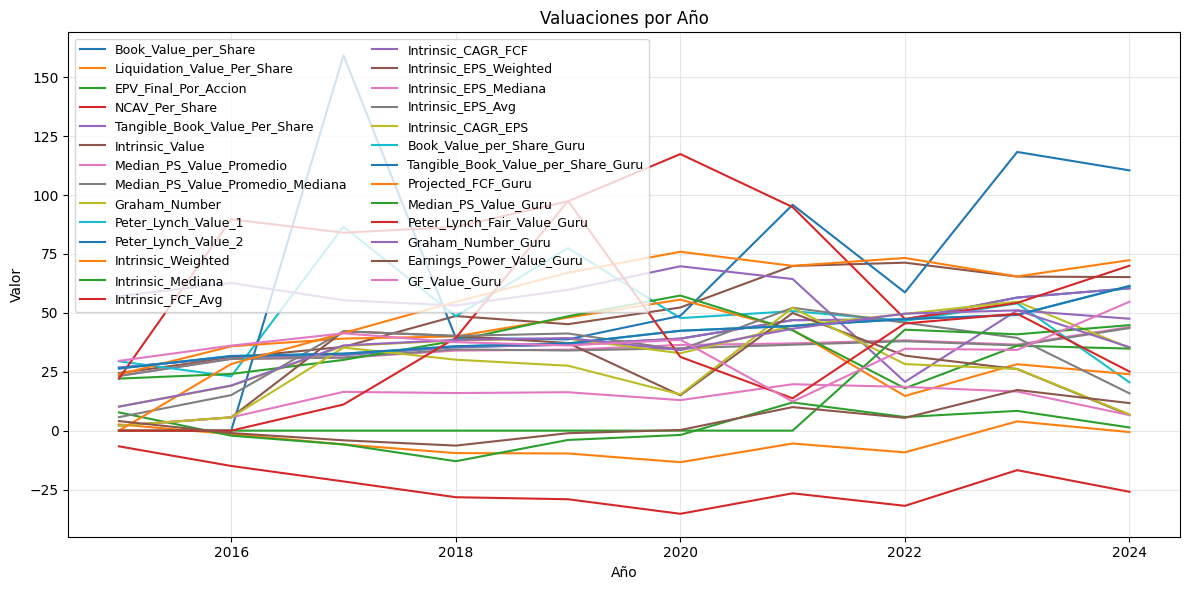

In [415]:

# Asegurar orden por Año
df_plot = df_valuaciones.sort_values("Año")

plt.figure(figsize=(12, 6))

for col in df_plot.columns[1:]:
    plt.plot(df_plot["Año"], df_plot[col], label=col)

plt.xlabel("Año")
plt.ylabel("Valor")
plt.title("Valuaciones por Año")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## Modelo de Targets

In [416]:
data_stock_modelo = pd.read_csv(archivo_stock + '.csv')
data_stock_modelo.drop(columns=["Vol.","Cierre","Apertura"],axis=1, inplace=True)
data_stock_modelo["Fecha"] = pd.to_datetime(
    data_stock_modelo["Fecha"],
    format="%Y-%m-%d"
)

In [417]:
prices = data_stock_modelo.copy()

prices["Fecha"] = pd.to_datetime(prices["Fecha"])

prices = prices.sort_values("Fecha").reset_index(drop=True)

prices.head()

,Fecha,Máximo,Mínimo
0,2012-07-16,14.728761,14.728761
1,2012-07-23,14.907057,14.728762
2,2012-07-30,14.922559,14.573719
3,2012-08-06,14.922565,14.519461
4,2012-08-13,15.038844,14.728765


In [418]:
mes_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

headers_df = pd.DataFrame({
    "Header": valid_headers
})

headers_df["Mes"] = headers_df["Header"].str[:3].map(mes_map)
headers_df["Año"] = headers_df["Header"].str[-4:].astype(int)

# Fecha base = primer día del mes del header
headers_df["Fecha_base"] = pd.to_datetime(
    headers_df["Año"].astype(str) + "-" +
    headers_df["Mes"].astype(str).str.zfill(2) + "-01"
)

headers_df["Fecha_teorica"] = headers_df["Fecha_base"] + pd.DateOffset(months=1)

valuations = df_valuaciones.copy()

valuations = valuations.merge(
    headers_df[["Año", "Fecha_teorica"]],
    on="Año",
    how="left"
)

In [419]:
price_dates = prices[["Fecha"]]

valuations = pd.merge_asof(
    valuations.sort_values("Fecha_teorica"),
    price_dates.sort_values("Fecha"),
    left_on="Fecha_teorica",
    right_on="Fecha",
    direction="forward"
)

valuations = valuations.rename(columns={"Fecha": "Fecha_base"})

valuations[["Año", "Fecha_teorica", "Fecha_base"]].head()


,Año,Fecha_teorica,Fecha_base
0,2015,2016-01-01,2016-01-04
1,2016,2017-01-01,2017-01-02
2,2017,2018-01-01,2018-01-01
3,2018,2019-01-01,2019-01-07
4,2019,2020-01-01,2020-01-06


In [ ]:
id_cols = ["Año", "Fecha_base"]

valuations = valuations.loc[:, ~valuations.columns.duplicated()].copy()

# Seleccionar SOLO columnas de métodos (numéricas) y excluir id_cols
method_cols = [
    c for c in valuations.columns
    if c not in id_cols and pd.api.types.is_numeric_dtype(valuations[c])
]

valuations_long = valuations.melt(
    id_vars=id_cols,
    value_vars=method_cols,
    var_name="Metodo",
    value_name="Valor"
)

# Forzar a numérico y limpiar
valuations_long["Valor"] = pd.to_numeric(valuations_long["Valor"], errors="coerce")
valuations_long = valuations_long.dropna(subset=["Valor"])


In [421]:
valuations_long

,Año,Fecha_base,Metodo,Valor
0,2015,2016-01-04,Book_Value_per_Share,26.742307
1,2016,2017-01-02,Book_Value_per_Share,31.203987
2,2017,2018-01-01,Book_Value_per_Share,32.146785
3,2018,2019-01-07,Book_Value_per_Share,35.448960
4,2019,2020-01-06,Book_Value_per_Share,36.495236
...,...,...,...,...
265,2020,2021-01-04,GF_Value_Guru,38.580000
266,2021,2022-01-03,GF_Value_Guru,12.340000
267,2022,2023-01-02,GF_Value_Guru,34.750000
268,2023,2024-01-01,GF_Value_Guru,34.270000


In [ ]:
tol = 0.05
H = 156

# Asegurar datetime y orden
prices["Fecha"] = pd.to_datetime(prices["Fecha"])
prices = prices.sort_values("Fecha").reset_index(drop=True)

HIGH_COL = "Máximo"
LOW_COL  = "Mínimo"

# Chequeos rápidos
assert prices["Fecha"].is_monotonic_increasing
assert {HIGH_COL, LOW_COL}.issubset(prices.columns)
assert {"Fecha_base", "Metodo", "Valor"}.issubset(valuations_long.columns)

In [424]:
valuations_long["L"] = valuations_long["Valor"] * (1 - tol)
valuations_long["U"] = valuations_long["Valor"] * (1 + tol)


In [425]:
valuations_long["Fecha_fin"] = valuations_long["Fecha_base"] + pd.to_timedelta(H, unit="W")


In [ ]:
prices["Fecha"] = pd.to_datetime(prices["Fecha"], errors="coerce")

# Limpieza: quitar comas de miles y convertir a float
for c in [HIGH_COL, LOW_COL]:  # ej. "Máximo", "Mínimo"
    prices[c] = (
        prices[c]
        .astype(str)
        .str.replace(",", "", regex=False)   # 2,039.76 -> 2039.76
        .str.replace(" ", "", regex=False)
    )
    prices[c] = pd.to_numeric(prices[c], errors="coerce")

prices = prices.dropna(subset=["Fecha", HIGH_COL, LOW_COL]).sort_values("Fecha").reset_index(drop=True)

In [427]:
def first_hit(fecha_base, fecha_fin, valor, L, U):
    if valor is None or pd.isna(valor) or valor <= 0:
        return np.nan, np.nan, pd.NaT, pd.NA

    w = prices.loc[
        (prices["Fecha"] >= fecha_base) & (prices["Fecha"] <= fecha_fin),
        ["Fecha", HIGH_COL, LOW_COL]
    ]

    if w.empty:
        return False, np.nan, pd.NaT, pd.NA

    base_high = w.iloc[0][HIGH_COL]
    base_low  = w.iloc[0][LOW_COL]
    p_base = (base_high + base_low) / 2

    if p_base < L:
        side = "long"
    elif p_base > U:
        side = "short"
    else:
        side = "at_target"  

    hit_mask = (w[LOW_COL] <= U) & (w[HIGH_COL] >= L)
    if not hit_mask.any():
        return False, np.nan, pd.NaT, side

    first_pos = int(np.argmax(hit_mask.to_numpy()))
    hit_date = w.iloc[first_pos]["Fecha"]
    tth_weeks = first_pos

    return True, tth_weeks, hit_date, side


In [428]:
hits = valuations_long.apply(
    lambda r: first_hit(r["Fecha_base"], r["Fecha_fin"], r["Valor"], r["L"], r["U"]),
    axis=1,
    result_type="expand"
)

hits.columns = ["hit", "tth_weeks", "hit_date", "side"]
valuations_long[["hit", "tth_weeks", "hit_date", "side"]] = hits


In [429]:
valuations_long.to_excel('valuaciones_long_format.xlsx', index=False)

In [ ]:
valuations_long[["Año","Metodo","Valor","Fecha_base","hit","tth_weeks","hit_date"]]

# Convertir NaT -> NaN en hit (y cualquier cosa rara)
valuations_long["hit"] = valuations_long["hit"].replace({pd.NaT: np.nan})

# Fuerza dtype booleano nullable 
valuations_long["hit"] = valuations_long["hit"].astype("boolean")


In [431]:
summary = (
    valuations_long
    .groupby("Metodo", as_index=False)
    .agg(
        targets=("hit", "count"),       
        hits=("hit", "sum"),              
        hit_rate=("hit", "mean"),        
        median_tth=("tth_weeks", "median"),
        avg_tth=("tth_weeks", "mean"),
    )
)

for years, weeks in [(1, 52), (2, 104), (3, 156)]:
    col = f"hit_le_{years}y"

    tmp = valuations_long["hit"] & (valuations_long["tth_weeks"] <= weeks)

    summary[col] = (
        valuations_long
        .assign(_tmp=tmp)
        .groupby("Metodo")["_tmp"]
        .mean()            
        .values
    )

summary = summary.sort_values(
    ["hit_rate", "median_tth"],
    ascending=[False, True]
).reset_index(drop=True)


In [432]:
metodos_top = summary.loc[summary["hit_rate"] >= 0.60, "Metodo"]

df_hits_por_anio = (
    valuations_long
    .loc[
        valuations_long["Metodo"].isin(metodos_top),
        ["Año", "Metodo", "Valor", "hit", "tth_weeks", "hit_date","side"]
    ]
    .sort_values(["Metodo", "Año"])
    .reset_index(drop=True)
)

df_hits_por_anio

,Año,Metodo,Valor,hit,tth_weeks,hit_date,side
0,2015,Book_Value_per_Share,26.742307,True,42.0,2016-10-24,long
1,2016,Book_Value_per_Share,31.203987,True,138.0,2019-08-26,long
2,2017,Book_Value_per_Share,32.146785,True,93.0,2019-10-14,long
3,2018,Book_Value_per_Share,35.448960,True,51.0,2019-12-30,long
4,2019,Book_Value_per_Share,36.495236,True,1.0,2020-01-13,long
...,...,...,...,...,...,...,...
135,2020,Tangible_Book_Value_per_Share_Guru,42.396000,True,0.0,2021-01-04,long
136,2021,Tangible_Book_Value_per_Share_Guru,44.455000,True,42.0,2022-10-24,long
137,2022,Tangible_Book_Value_per_Share_Guru,47.321000,True,0.0,2023-01-02,at_target
138,2023,Tangible_Book_Value_per_Share_Guru,49.141000,True,30.0,2024-07-29,short


In [433]:
df_hits_por_anio.to_excel(f'valuaciones_hits_por_anio_{ticket}.xlsx', index=False)

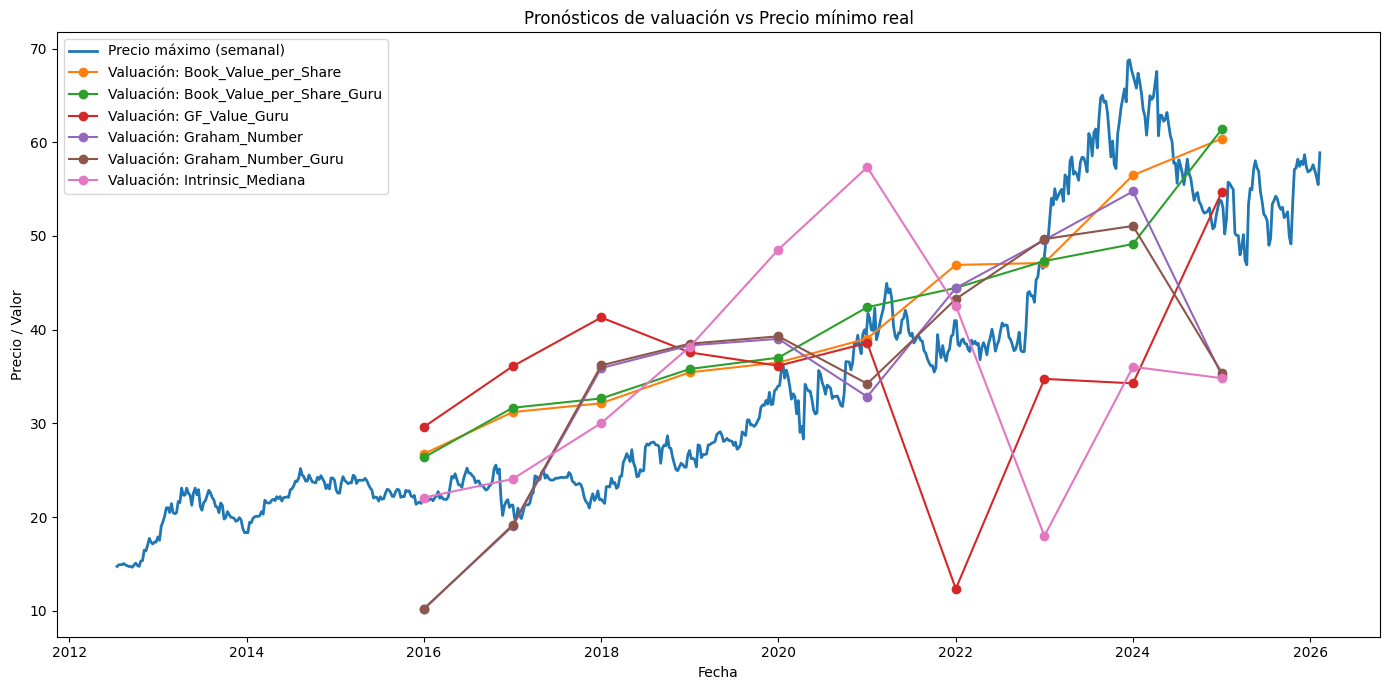

In [434]:
prices = prices.copy()
prices["Fecha"] = pd.to_datetime(prices["Fecha"], errors="coerce")
prices = prices.dropna(subset=["Fecha"]).sort_values("Fecha")

df_hits = df_hits_por_anio.copy()
df_hits["Año"] = df_hits["Año"].astype(int)
df_hits["Valor"] = pd.to_numeric(df_hits["Valor"], errors="coerce")


mes_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

headers_df = pd.DataFrame({"Header": valid_headers})
headers_df["Mes"] = headers_df["Header"].str[:3].map(mes_map)
headers_df["Año"] = headers_df["Header"].str[-4:].astype(int)

headers_df["Fecha_base"] = pd.to_datetime(
    headers_df["Año"].astype(str) + "-" +
    headers_df["Mes"].astype(str).str.zfill(2) + "-01",
    errors="coerce"
)
headers_df["Fecha_teorica"] = headers_df["Fecha_base"] + pd.DateOffset(months=1)

df_hits = df_hits.merge(
    headers_df[["Año", "Fecha_teorica"]],
    on="Año",
    how="left"
)

df_hits["Fecha_teorica"] = df_hits["Fecha_teorica"].fillna(
    pd.to_datetime((df_hits["Año"] + 1).astype(str) + "-01-01")
)


metodos_plot = (
    df_hits[df_hits["Valor"] > 0]
    .groupby("Metodo")["Valor"]
    .count()
    .sort_values(ascending=False)
    .head(6)          
    .index
)

df_hits_plot = df_hits[df_hits["Metodo"].isin(metodos_plot)].copy()


plt.figure(figsize=(14, 7))

plt.plot(
    prices["Fecha"],
    prices["Máximo"],
    label="Precio máximo (semanal)",
    linewidth=2
)

for metodo, g in df_hits_plot.groupby("Metodo"):
    g = (
        g.dropna(subset=["Fecha_teorica", "Valor"])
         .sort_values("Fecha_teorica")
    )
    g = g[g["Valor"] > 0]  
    plt.plot(
        g["Fecha_teorica"],
        g["Valor"],
        marker="o",
        linewidth=1.5,
        label=f"Valuación: {metodo}"
    )

plt.title("Pronósticos de valuación vs Precio mínimo real")
plt.xlabel("Fecha")
plt.ylabel("Precio / Valor")
plt.legend()
plt.tight_layout()
plt.show()
